# ***Modelo de clasificación para la prevención de la mora bancaria***




Este proyecto desarrolla un modelo de clasificación orientado al área de Gestión de Riesgos, abordando un problema real de análisis supervisado: clasificar nuevos clientes según su posibilidad de cometer mora o no pago bancario a partir de su perfíl comercial.

A través de la integración de técnicas de clasificación (Random Forest, feauture importance) se construye un sistema capaz de identificar clientes que puedan incurrir en mora.

La solución está dirigida a:

| Stakeholder | Necesidad principal |
|---|---|
| Área de riesgo crediticio | Mejorar políticas de aprobación de créditos |
| Área comercial | Ofrecer productos adecuados al riesgo crediticio del cliente |
| Área de cobranzas | Campañas preventivas y renegociación crediticia |

## **Índice del Notebook**
1. Contexto Comercial y Problemática
2. Data Acquisition
3. Data Understanding
4. Data Wrangling
5. Feature Engineering
6. EDA (Univariado, Bivariado, Multivariado)
7. Modelado (Random Forest)
8. Evaluación
9. Segmentación de perfiles de riesgo
10. Conclusiones y Recomendaciones de Negocio


## **Contexto Comercial y Problemática**

El area de riesgo crediticio enfrenta un desafio crítico en la actualidad: **evitar que una expanción del total y monto de créditos asignados derive en pérdidas económicas por mora generalizada**. Si bien la mora se considera un riesgo menor al fraude, en contextos macro económicos carácterizados por la reseción ecónomica y pérdida del poder adquisitivo real, el incremento en la morosidad afecta drásticamente la salud financiera de bancos y fintech. En consecuencia, las empresas sufren pérdidas económicas y reducción de su valor bursatil.

***Variable objetivo***

- Mora

**Puntos de dolor identificados:**

**Masividad de Clientes morosos**

- Se otorgan créditos masivos de montos relativamente bajos que no tienen retorno en los plazos esperados.

**Creditos no pagados**

- Un porcentaje de los clientes morosos no pagan sus créditos y la probabilidad de recuperación es baja.

**Decisiones basadas en intuición:**

- La actual clasificación del cliente y score se basa principalmente en su trayectoria bancaria. Estas clasificaciones son eficaces en contextos de estabilidad económica. Sin embargo, en contextos recesivos es necesario evaluar la posibilidad de mora masiva teniendo en cuenta el perfíl sociodemográfico del cliente, junto con su historial financiero.

**Hipótesis planteadas:**

- La clasificación de riesgo presenta debilidades para captar la probabilidad de incumplimiento de pago del cliente lo que favorece el crecimiento de la morosidad.


# Librerias y Data Adquisition

In [1]:
# Configuramos el entorno de Python en Google Colab
from google.colab import drive
import os

drive.mount("/content/drive")
print(os.getcwd())

os.chdir("/content/drive/My Drive")
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
/content/drive/My Drive


In [2]:
import sys
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!pip install jupyter-contrib-nbextensions

In [3]:
import pandas as pd
import numpy as np
from IPython.display import Markdown
import matplotlib.pyplot as plt
import seaborn as sns
import math
import missingno as msno
from sklearn.model_selection import train_test_split
from ydata_profiling import ProfileReport

/tmp/ipykernel_39464/943560440.py:9: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


#***Adquisición del dataset***

* Se utiliza un dataset de datos crediticios de Perú descargado de la plataforma Kaggle. El dataset cuenta con una dimensión de 8399 filas y 14 columnas.
* La razon por las cuales se selecciona este dataset radica principalmente en que se encuentra disponible para descargar y cuenta con más de 70% de clientes con mora, lo que lo hace un dataset significativo para el análisis de “mora masiva”.
* No obstante, la falta de información acerca del origen de los datos alerta sobre la fiabilidad del mismo. El elevado porcentaje de morosos y otras inconsistencias detectadas advierten de elevadas probabilidades de que se trate de un dataset sintético.
* A pesar de estas incosistencias, como el objetivo de este proyecto es formativo, intentaremos subsanar los déficits del dataset con el conocimiento y las habilidades aprendidas.


In [4]:
import kagglehub

print("se importa un dataset de riesgo crediticio de Kangle")
# Download latest version
path = kagglehub.dataset_download("luishcaldernb/morosidad")

print("Path to dataset files:", path)



se importa un dataset de riesgo crediticio de Kangle
Using Colab cache for faster access to the 'morosidad' dataset.
Path to dataset files: /kaggle/input/morosidad


In [5]:
import os

files = os.listdir(path)
print(files)

['data.csv']


# **Data Understanding**

En esta sección se busca comprander las carácteristicas del dataset a partir de la implementación de distintas tecnicas de analisis de datos.
* descripción de las variables del dataset
* Detección de valores nulos, duplicados y outsiders.
* Reporte del dataset (distribución de variables, ceros y medidas de tendencia central)

In [6]:
print("Abrimos el dataset y observamos su dimensión:")
fraud_1 = pd.read_csv(os.path.join(path, 'data.csv'))
fraud_1.head()
print(f"Shape del dataset: {fraud_1.shape}")
print(f"Filas: {fraud_1.shape[0]:,} | Columnas: {fraud_1.shape[1]}")

Abrimos el dataset y observamos su dimensión:
Shape del dataset: (8399, 14)
Filas: 8,399 | Columnas: 14


# Descripción de variables

El dataset contiene información demografica y de perfíl crediticio en 8399 clientes. Estas variables pueden agruparse de la siguiente manera:

| Grupo | Variables | Descripción |
|---|---|---|
| **Demográficas** | Vivienda, Edad, Días_lab, Ingresos, Zona, Nivel_educ, Nivel_ahorro | Perfil sociolaboral del cliente
| **Riesgo crediticio** | Mora, Atraso, Deuda_sf, Score	Calificación, Clasif_sbs | Perfeil de riesgo crediticio del cliente
| **experiencia financiera** | Línea_sf, Exp_sf | Experiencia con productos financieros

**Demográficas**



1.   Vivienda:	Tipo de vivienda del cliente
2.   Edad:	Edad del cliente.
3.   Días_lab:	Días laborados en su actual empleo.
4.   Nivel_ahorro:	Índice del nivel de ahorro del cliente (de 0 a 12. 0: no tiene ahorros,  12: alto nivel de ahorros)
5.   Ingreso:	Ingresos del cliente.
6.   Zona:	Departamento de residencia del cliente.
7.   Nivel_educ:	Nivel educativo máximo alcanzado por el cliente.

**Riesgo crediticio**

8.   Mora:	Morosidad del cliente (0: paga al día, 1: cliente moroso)
9. Atraso:	Atraso histórico del cliente en días.
10.  Deuda_sf:	Deuda del cliente en el sistema financiero
11.  Score	Calificación: crediticia del cliente. Mientras mayor es el score, mejor perfil crediticio tiene el cliente
12. Clasif_sbs:	Clasificación SBS. Mientras mayor es el número, peor clasificación tiene el cliente: {0: normal, 1: con problemas potenciales, 2: deficiente, 3: dudoso, 4: pérdida}

**experiencia financiera**

13. Exp_sf:	Meses con experiencia en el sistema financiero, es decir el número  de meses que tiene el cliente desde que adquirió algún producto financiero.
14. Línea_sf:	Línea de crédito en el sistema financiero que el cliente tiene disponible.







In [7]:
print("Analizamos los datos nulos y el tipo de datos de cada variables")
fraud_1.info()
print("")
print("Nulls: tres variables tienen null en una proporción moderada")
print("tipos de datos")
print(
    f"Flotantes: {fraud_1.select_dtypes(include=[np.float64]).shape[1]} | "
    f"Enteros: {fraud_1.select_dtypes(include=[np.int64]).shape[1]} | "
    f"Objetos: {fraud_1.select_dtypes(include=['object']).shape[1]}"
)

Analizamos los datos nulos y el tipo de datos de cada variables
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   object 
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   object 
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 918.8+ KB

Nulls: tres variables tienen null en una proporción moderada
tipos de datos


In [8]:
print("Descripción de variables float e int")
fraud_1.describe().T.round(2)

Descripción de variables float e int


,count,mean,std,min,25%,50%,75%,max
mora,8399.0,0.70,0.46,0.0,0.00,1.00,1.00,1.00
atraso,8399.0,4.46,14.27,0.0,0.00,0.00,2.00,245.00
edad,8399.0,36.40,9.83,20.0,29.00,34.00,42.00,85.00
dias_lab,8399.0,5555.89,2153.24,2956.0,4174.00,4904.00,6182.00,20700.00
exp_sf,6569.0,32.40,32.87,0.0,7.00,20.00,51.00,130.00
nivel_ahorro,8399.0,10.59,3.37,0.0,12.00,12.00,12.00,12.00
ingreso,8399.0,4350.41,5367.06,123.7,1366.67,2400.00,4900.00,30000.00
linea_sf,7272.0,11987.24,21322.80,0.0,1169.37,4030.12,12086.63,121543.40
deuda_sf,7938.0,6110.72,11177.99,0.0,478.32,2258.76,5755.15,57094.38
score,8399.0,196.62,19.54,134.0,182.00,197.00,212.00,266.00


In [9]:
print("Descripción de variables categóricas")
print(fraud_1.describe(include=['object']).T)

print()
for col in ['vivienda', 'zona', 'nivel_educ']:
    print(f"{col}:")
    print(fraud_1[col].value_counts())
    print()

Descripción de variables categóricas
           count unique            top  freq
vivienda    8399      3       FAMILIAR  5853
zona        8399     25           Lima  4980
nivel_educ  8399      4  UNIVERSITARIA  4802

vivienda:
vivienda
FAMILIAR     5853
PROPIA       2381
ALQUILADA     165
Name: count, dtype: int64

zona:
zona
Lima             4980
Callao            507
La Libertad       447
Arequipa          349
Ica               300
Lambayeque        279
Piura             279
Junin             263
Ancash            224
Cajamarca         173
Loreto            118
Cuzco              96
Ucayali            85
Pasco              53
Moquegua           46
San Martin         45
Huanuco            37
Tacna              32
Puno               23
Ayacucho           23
Tumbes             22
Apurimac            8
Madre de Dios       6
Huancavelica        3
Amazonas            1
Name: count, dtype: int64

nivel_educ:
nivel_educ
UNIVERSITARIA    4802
TECNICA          3288
SECUNDARIA        267
SIN E

In [10]:
display(Markdown("**Analisis de filas duplicadas**"))
print("")
print("Analizamos la cantidad de casos duplicados")
print("")
duplicados = fraud_1.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")
print("")
pct_dup = fraud_1.duplicated().mean() * 100
print(f"Porcentaje duplicado: {pct_dup:.2f}%")
duplicados = fraud_1[fraud_1.duplicated(keep=False)]
print("")
print("head de casos duplicados")
print(duplicados.sort_values(by=list(fraud_1.columns)).head(20))
print("")
print("el data set no cuenta con identificador de cliente e ID de fila que permita determinar si es un caso realmente duplicado o azar")
print("la coincidencia en variables float, sin embargo, presumen duplicación")

**Analisis de filas duplicadas**


Analizamos la cantidad de casos duplicados

Filas duplicadas: 2325

Porcentaje duplicado: 27.68%

head de casos duplicados
      mora  atraso   vivienda  edad  dias_lab  exp_sf  nivel_ahorro  ingreso  \
1233     0       0  ALQUILADA    29      4904    31.0            12  4595.70   
7241     0       0  ALQUILADA    29      4904    31.0            12  4595.70   
1018     0       0  ALQUILADA    37      3981    87.0            12  5000.00   
5957     0       0  ALQUILADA    37      3981    87.0            12  5000.00   
6034     0       0  ALQUILADA    37      3981    87.0            12  5000.00   
5283     0       0  ALQUILADA    55      4251     0.0            12  2372.72   
7381     0       0  ALQUILADA    55      4251     0.0            12  2372.72   
5129     0       0   FAMILIAR    21      3626     0.0            12   900.00   
5523     0       0   FAMILIAR    21      3626     0.0            12   900.00   
6201     0       0   FAMILIAR    21      3626     0.0            12   900.00

In [11]:
#Eliminamos datos duplicados en esta etapa porque compromete las visualizaciones con las que finalizaremos el dataunderstand
print("Anticipamos la eliminación de filas duplicadas porque abarcan un 27% del dataset y puede comprometer la comprensión del mismo")
fraud_1 = fraud_1.drop_duplicates()
print(f"Shape del dataset: {fraud_1.shape}")
print(f"Filas: {fraud_1.shape[0]:,} | Columnas: {fraud_1.shape[1]}")

Anticipamos la eliminación de filas duplicadas porque abarcan un 27% del dataset y puede comprometer la comprensión del mismo
Shape del dataset: (6074, 14)
Filas: 6,074 | Columnas: 14


In [12]:
display(Markdown("**Analisis de valores faltantes**"))
print("")
print("Analizamos en que columnas se encuentran los datos nulos y el total de nulos")
print("")
print(fraud_1.isnull().sum())
# Valores faltantes
print("")
print("observamos el porcentaje de valores nulos en variables con datos nulos")
print("")
nulos = fraud_1.isnull().sum()
nulos_pct = (nulos / len(fraud_1) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
print(nulos_df[nulos_df['Nulos'] > 0])

**Analisis de valores faltantes**


Analizamos en que columnas se encuentran los datos nulos y el total de nulos

mora               0
atraso             0
vivienda           0
edad               0
dias_lab           0
exp_sf          1805
nivel_ahorro       0
ingreso            0
linea_sf        1113
deuda_sf         451
score              0
zona               0
clasif_sbs         0
nivel_educ         0
dtype: int64

observamos el porcentaje de valores nulos en variables con datos nulos

          Nulos  % del total
exp_sf     1805        29.72
linea_sf   1113        18.32
deuda_sf    451         7.43


In [13]:
#creamos un reporte de las distintas variables del data set
profile = ProfileReport(fraud_1, title="YData Profiling Report")
profile

*** Insight reporte***


### **Tabla Resumen Distribucional**

| Variable | Interpretación |
|---|---|
| Mora |  Variable binaria desequilibrada -  4313 casos (71%) son "mora" y 1761 (39%) "no mora" |
| Atraso | Sesgo positivo pronunciado — muchos clientes sin atraso pocos con atraso distribuido entre 1 y 250 días  |
| Edad | Distribución levemente asimétrica — Clientes jóvenes de 30 a 40 años  |
| días lab |  Sesgo positivo - promedio de 5000 dias|
| experiencia financiera |  Sesgo positivo — mayoría con pocos meses en el sistema financiero, pocos con muchos meses |
| Nivel de ahorro | Variable Categorica — la mayoría de los clientes son clasificados con alta capacidad de ahorro. Un dato llamativo frente a la gran mora |
| ingresos |  Sesgo positivo-  mucho clientes con ingresos medios y pocos con altos ingresos |
| Linea sf | Sesgo positivo pronunciado — muchos créditos de bajo monto y y pocos de alto monto |
| Deuda | Sesgo positivo pronunciado— muchos clientes sin deuda o con bajo monto de deuda y pocos con deudad elevadas|
| score |  Distribución uniforme |
| distribución de clasificación |  Sesgo positivo pronunciado — Muchos con buena clasificacion y pocos con mala. Un dato llamativo frente al número de morosos|
| zona | Variable categorica - aproximadamente el 50% de los casos se concentran en Lima|
| Vivienda| Variable categórica - el 70% vivienda familiar, 28% propia y 2% alquilada-
| Educación | Variable Categorica -54% Universidad, 41% Tecnica, Secundaria 4%, sin educación 1%. Clientes con alta formación |


# ***Data Wrangling - Limpieza y transofrmación de datos***

En esta sección analizamos las caracteristicas de los valores faltantes y outliers.
porque se aplico en la sección previa.
1. Analisis y transformación de valores faltantes
2. Analisis y transformación de valores outliers
3. No se realiza analisis y eliminación de duplicados porque se implemento en sección previa.

observamos el patrón de datos nulos y analisamos si existe correlación entre los mismos
Leve correlación positiva linea_sf y exp_sf. Concluimos que missing at random


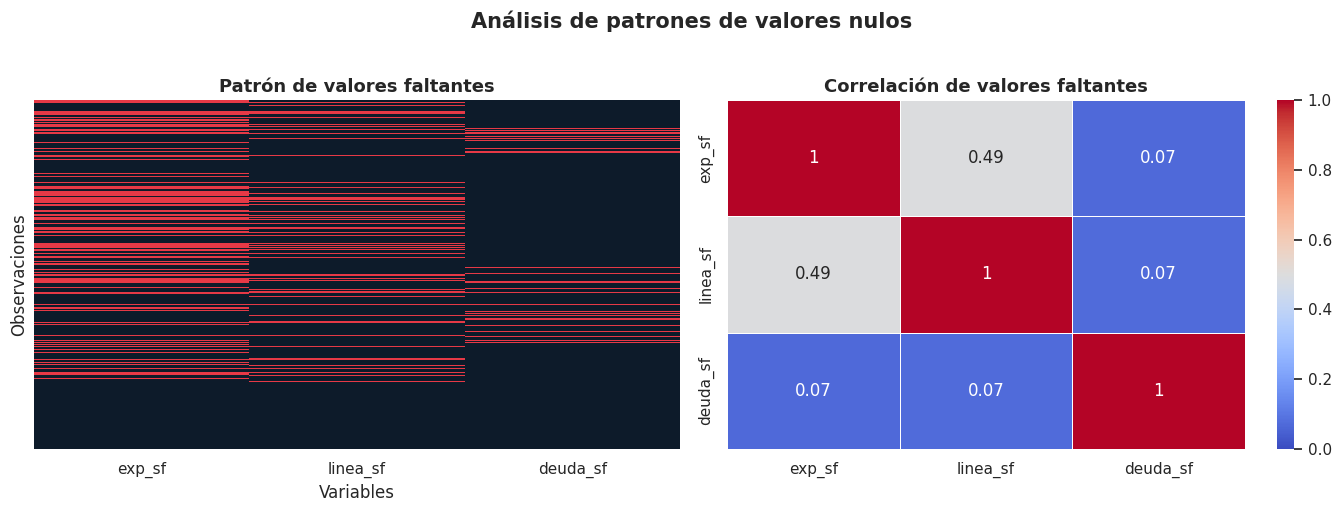

In [14]:
# analisis de valores nulos
print("observamos el patrón de datos nulos y analisamos si existe correlación entre los mismos")
print("Leve correlación positiva linea_sf y exp_sf. Concluimos que missing at random")

DF_Nuls = ['exp_sf', 'linea_sf', 'deuda_sf']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Heatmap de patrón de nulls =====

sns.heatmap(
    fraud_1[DF_Nuls].isnull(),
    cbar=False,
    yticklabels=False,
    cmap=['#0d1b2a', '#e63946'],
    ax=axes[0]
)

axes[0].set_title(
    "Patrón de valores faltantes",
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel("Variables")
axes[0].set_ylabel("Observaciones")


# ===== Correlación de nulls =====

sns.heatmap(
    fraud_1[DF_Nuls].isnull().corr(),
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title(
    "Correlación de valores faltantes",
    fontsize=13,
    fontweight='bold'
)

plt.suptitle(
    "Análisis de patrones de valores nulos",
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

In [15]:
# Debido a una distribición con sesgo positivo se reemplaza valores faltantes por la mediana
print("reemplazamos los datos null con la mediana debido a la distribución sesgada de datos")
print("al mismo tiempo, debido al porcentaje relevante de nulos creamos 3 columnas nuevas de flag con el objetivo de analizar si el null es un dato significativo")

fraud_1["exp_sf_missing"] = fraud_1["exp_sf"].isnull().astype(int)
fraud_1["linea_sf_missing"] = fraud_1["linea_sf"].isnull().astype(int)
fraud_1["deuda_sf_missing"] = fraud_1["deuda_sf"].isnull().astype(int)

# Imputamos con la mediana

fraud_1["exp_sf"] = fraud_1["exp_sf"].fillna(fraud_1["exp_sf"].median())
fraud_1["linea_sf"] = fraud_1["linea_sf"].fillna(fraud_1["linea_sf"].median())
fraud_1["deuda_sf"] = fraud_1["deuda_sf"].fillna(fraud_1["deuda_sf"].median())
print("")
print("observamos datos nulos y nuevas columnas")
#comprobamos que no hay nulls
fraud_1.isnull().sum()


reemplazamos los datos null con la mediana debido a la distribución sesgada de datos
al mismo tiempo, debido al porcentaje relevante de nulos creamos 3 columnas nuevas de flag con el objetivo de analizar si el null es un dato significativo

observamos datos nulos y nuevas columnas


,0
mora,0
atraso,0
vivienda,0
edad,0
dias_lab,0
exp_sf,0
nivel_ahorro,0
ingreso,0
linea_sf,0
deuda_sf,0


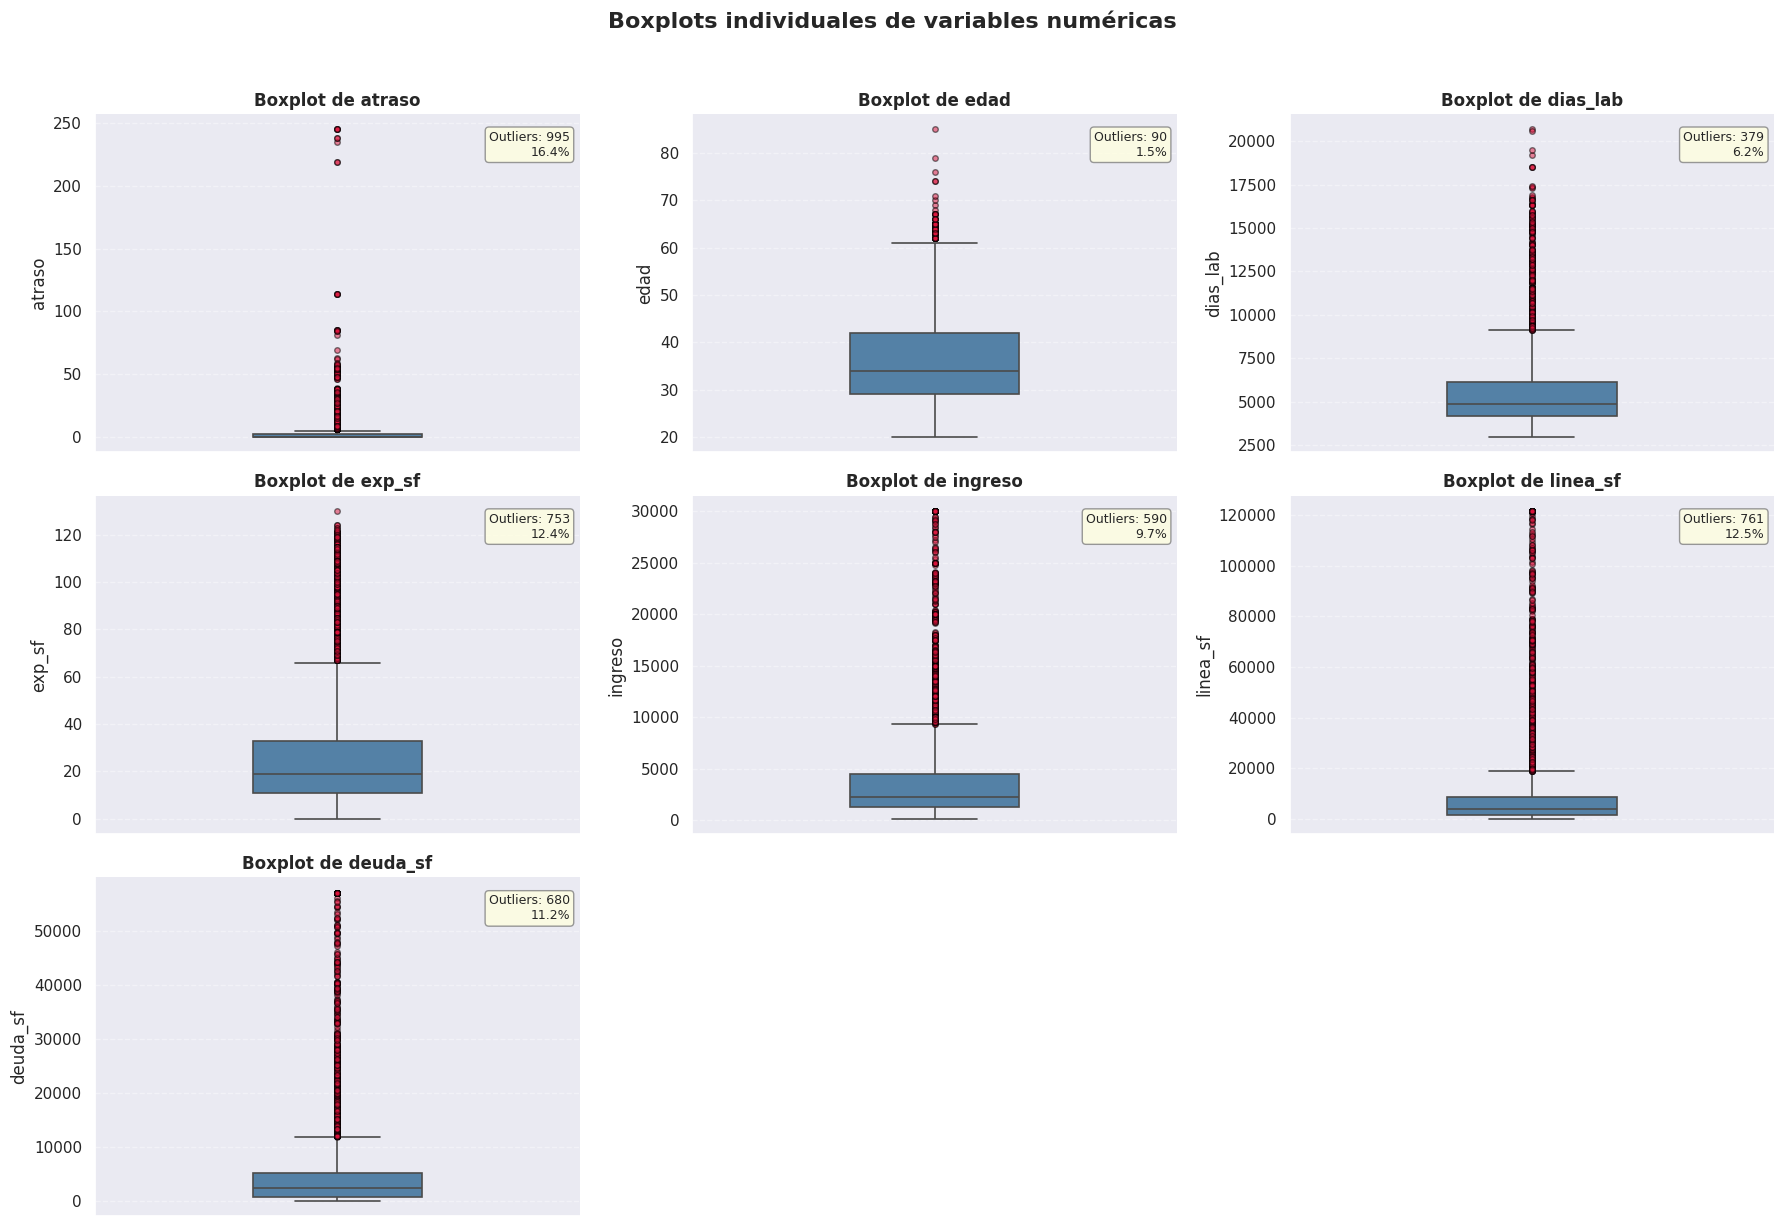

In [16]:
# Analisis y visualización de valores outliers
# La visualizacion de boxplost muestra columnas con gran cantidad de datos candidatos a ser considerados outliers.

import math
import matplotlib.pyplot as plt
import seaborn as sns


exclude_cols = [
    'mora',
    'nivel_ahorro',
    'clasif_sbs',
    'exp_sf_missing',
    'linea_sf_missing',
    'deuda_sf_missing',
    'score'
]

fraud_numeric = fraud_1.select_dtypes(include=['number']) \
                       .drop(columns=exclude_cols)



# Configuración de grilla
n_cols = 3
n_rows = math.ceil(len(fraud_numeric.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(fraud_numeric.columns):

    sns.boxplot(
        y=fraud_numeric[col].dropna(),
        ax=axes[i],
        color='steelblue',
        width=0.35,
        linewidth=1.2,
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'crimson',
            'markeredgecolor': 'black',
            'markersize': 4,
            'alpha': 0.5
        }
    )

    q1 = fraud_numeric[col].quantile(0.25)
    q3 = fraud_numeric[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = fraud_numeric[
        (fraud_numeric[col] < lower_limit) |
        (fraud_numeric[col] > upper_limit)
    ][col]

    axes[i].set_title(
        f'Boxplot de {col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    axes[i].text(
        0.98,
        0.95,
        f'Outliers: {len(outliers)}\n{len(outliers)/len(fraud_numeric)*100:.1f}%',
        transform=axes[i].transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='lightyellow',
            edgecolor='gray',
            alpha=0.8
        )
    )

    sns.despine(ax=axes[i])

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Boxplots individuales de variables numéricas',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### **Tabla Resumen de outliers**

| Variable |Cantidad de outliers |Descripción - Operación|
|---|---|---|
| Atraso | 995 outliers| Son atrasos pronunciados y quitarlos eliminaria información pertinente|
| Edad | 90 outliers| Clientes reales mayores de 60 años. No se eliminan porque no exceden los 100 años|
| dias_lab| 379 outliers| Superan los 17 mil días (46 años de trabajo) se considera dato erroneo|
| exp_sf | 753 outliers| Clientes con 10 o más años como clientes, correponde a antigüedad posible|
| ingreso| 590 outliers| Cliente con alto poder adquisitivo. No se eliminan porque pierde información de clientes de altos ingresos|
| linea sf| 761 outliers| Créditos elevados. No se eliminan porque responden a financiaciones altas posibles|
| deuda_sf| 680 outliers| Deuda elevada. No se elimina porque responde a deuda alta posible|


Se utiliza logaritmo para suavizar outliers y distribución sesgada de variables determinadas

In [17]:
print("Se detectaron valores extremos en la variable dias_lab, algunos superiores a 17.000 días laborales.")
print("Dado que dichos valores podrían corresponder tanto a errores como a clientes de edad avanzada o jubilados")
print("se decide contextualizar los outliers cruzándolos con la variable edad antes de aplicar transformaciones o exclusiones automáticas")
print("")
print("Se descubre que la edad de inicio laboral es menor a los 14 años, dando cuenta de un posible error en la carga de datos")
print("")

q1 = fraud_1['dias_lab'].quantile(0.25)
q3 = fraud_1['dias_lab'].quantile(0.75)

iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

outliers_dias = fraud_1[fraud_1['dias_lab'] > upper_limit]

outliers_dias[['edad', 'dias_lab']].sort_values(by='dias_lab', ascending=False)

outliers_dias['anios_lab'] = outliers_dias['dias_lab'] / 365

outliers_dias[['edad', 'dias_lab', 'anios_lab']] \
    .sort_values(by='dias_lab', ascending=False)


outliers_dias['edad_inicio_laboral'] = (
outliers_dias['edad']
- (outliers_dias['dias_lab'] / 365)
)

outliers_dias[
    ['edad', 'dias_lab', 'anios_lab', 'edad_inicio_laboral']
].sort_values(by='dias_lab', ascending=False)



Se detectaron valores extremos en la variable dias_lab, algunos superiores a 17.000 días laborales.
Dado que dichos valores podrían corresponder tanto a errores como a clientes de edad avanzada o jubilados
se decide contextualizar los outliers cruzándolos con la variable edad antes de aplicar transformaciones o exclusiones automáticas

Se descubre que la edad de inicio laboral es menor a los 14 años, dando cuenta de un posible error en la carga de datos



/tmp/ipykernel_39464/287095011.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_dias['anios_lab'] = outliers_dias['dias_lab'] / 365
/tmp/ipykernel_39464/287095011.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_dias['edad_inicio_laboral'] = (


,edad,dias_lab,anios_lab,edad_inicio_laboral
690,64,20700,56.712329,7.287671
1498,65,20580,56.383562,8.616438
2046,64,19484,53.380822,10.619178
1199,67,19207,52.621918,14.378082
4959,65,18518,50.734247,14.265753
...,...,...,...,...
4771,36,9165,25.109589,10.890411
1917,62,9165,25.109589,36.890411
4966,41,9134,25.024658,15.975342
4987,37,9134,25.024658,11.975342


# Transformación de outliers

In [18]:
# Se transforma outliers de dias_lab utilizando criterios intuitivos y estadisticos.
# En primer lugar, se observa que un número significativo de outliers corresponde a clientes mayores de 65 años que podrían percibir un haber jubilatorio.
# En este caso se imputa un valor que represente 40 años de días laborales (40 * 365) a los clientes mayores a 54 años. Teniendo en cuenta inicio de edad laboral 14 años y 40 años de trabajo
# En segundo lugar, para los clientes menores de 54 años se imputa la mediana, dado el sesgo de datos.

print("se transforman outliers en base a criterior estadisticos e intuitivos")
print("Los outliers de clientes mayores a 54 años se le imputa el resultado de 40 años de actividad laboral (365*40). Considerando que pudieron comenzar a trabajar a los 14 años")
print("Los clientes de menos de 54 años se les imputa la mediana")


# Primero se calcula límites IQR

q1 = fraud_1['dias_lab'].quantile(0.25)
q3 = fraud_1['dias_lab'].quantile(0.75)

iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

## Se calcula la mediana

mediana_dias = fraud_1['dias_lab'].median()

# Crear máscaras ANTES de modificar
mask_mayores = (
    (fraud_1['dias_lab'] > upper_limit) &
    (fraud_1['edad'] > 54)
)

mask_menores = (
    (fraud_1['dias_lab'] > upper_limit) &
    (fraud_1['edad'] <= 54)
)

# Guardar conteos
n_mayores = mask_mayores.sum()
n_menores = mask_menores.sum()

# Transformar
fraud_1.loc[mask_mayores, 'dias_lab'] = 40 * 365

fraud_1.loc[mask_menores, 'dias_lab'] = fraud_1['dias_lab'].median()

# Mostrar resultados guardados
print(f"Outliers corregidos (>54 años): {n_mayores}")
print(f"Outliers corregidos (<=54 años): {n_menores}")

se transforman outliers en base a criterior estadisticos e intuitivos
Los outliers de clientes mayores a 54 años se le imputa el resultado de 40 años de actividad laboral (365*40). Considerando que pudieron comenzar a trabajar a los 14 años
Los clientes de menos de 54 años se les imputa la mediana
Outliers corregidos (>54 años): 107
Outliers corregidos (<=54 años): 272


# ***Feature Engeeniering***
En esta sección se crean y transofrman variables con la finalidad de mejorar la capacidad predictiva del modelo:

* Se crean nuevas variables para mejorar la predicción
* tranformación de variables object en variables númericas que se utilizaran en el modelado
* recodificación de lugar de resitencia por zona para reducir la dispersión de datos

Creación de variable ratio para mejorar predicción


In [19]:
# creo una columna ratio deuda y monto de crédito.
fraud_1['ratio_deuda_linea'] = fraud_1['deuda_sf'] / (fraud_1['linea_sf'] + 1)

# Transformación de variables object en variables númericas
combinación de método dummines one-hot con map

In [20]:
# transformación de variables object en numericas método one-hot
# realizo una copia de la columna para no perder datos antes del EDA
fraud_1["vivienda_desagregada"] = fraud_1["vivienda"]
#Transformo en tres columnas one-hot
fraud_1 = pd.get_dummies(fraud_1, columns= ['vivienda_desagregada'])

In [21]:
# se tranforman datos categoricos de educación a númericos con orden
fraud_1["educ_desagregada"] = fraud_1["nivel_educ"]
# dado que nivel educativo tiene un orden jerarquico revisamos las categorias
print(fraud_1["educ_desagregada"].value_counts())
# map valores en orden jerarquico ascendente
educ_map = {
    'SIN EDUCACION': 0,
    'SECUNDARIA': 1,
    'TECNICA': 2,
    'UNIVERSITARIA': 3
}

fraud_1['nivel_educ_map'] = fraud_1['educ_desagregada'].map(educ_map)
print(fraud_1['nivel_educ_map'].value_counts())

educ_desagregada
UNIVERSITARIA    3298
TECNICA          2524
SECUNDARIA        223
SIN EDUCACION      29
Name: count, dtype: int64
nivel_educ_map
3    3298
2    2524
1     223
0      29
Name: count, dtype: int64


In [22]:
#analizo cántas variables tiene zona antes de decidir cómo transformarla
print(fraud_1['zona'].value_counts())

#  zona cuenta con 25 variables y la mayor cantidad de casos se concentra en lima
# las agrupamos en 3 variables para no incrementar en exceso la dimensiónalidad

zona_map = {
    'Lima': 'costa',
    'Callao': 'costa',
    'Piura': 'costa',
    'Lambayeque': 'costa',
    'La Libertad': 'costa',
    'Ica': 'costa',
    'Tumbes': 'costa',

    'Cusco': 'sierra',
    'Puno': 'sierra',
    'Ayacucho': 'sierra',
    'Huancavelica': 'sierra',
    'Apurimac': 'sierra',
    'Junin': 'sierra',
    'Pasco': 'sierra',
    'Cajamarca': 'sierra',
    'Huanuco': 'sierra',
    'Ancash': 'sierra',

    'Loreto': 'selva',
    'Ucayali': 'selva',
    'Madre de Dios': 'selva',
    'San Martin': 'selva',
    'Amazonas': 'selva'
}


#transformo las variables categoricas de zona en númericas con map
fraud_1['zona_macro'] = fraud_1['zona'].map(zona_map)

zona
Lima             3519
Callao            374
La Libertad       329
Arequipa          246
Ica               221
Piura             219
Junin             215
Lambayeque        206
Ancash            154
Cajamarca         121
Loreto             88
Cuzco              70
Ucayali            67
Pasco              45
San Martin         33
Moquegua           33
Huanuco            32
Tacna              28
Tumbes             21
Ayacucho           19
Puno               18
Apurimac            7
Madre de Dios       5
Huancavelica        3
Amazonas            1
Name: count, dtype: int64


In [23]:
#transformo las variables categoricas de zona en númericas con map
fraud_1['zona_macro'] = fraud_1['zona'].map(zona_map)
fraud_1['zona_macro_desagregado'] = fraud_1['zona_macro']
#
pd.get_dummies(fraud_1['zona_macro_desagregado'])

#
fraud_1 = pd.get_dummies(fraud_1, columns=['zona_macro_desagregado'])

fraud_1.head()


,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,...,ratio_deuda_linea,vivienda_desagregada_ALQUILADA,vivienda_desagregada_FAMILIAR,vivienda_desagregada_PROPIA,educ_desagregada,nivel_educ_map,zona_macro,zona_macro_desagregado_costa,zona_macro_desagregado_selva,zona_macro_desagregado_sierra
0,0,235,FAMILIAR,30,3748,93.0,5,3500.0,3725.00,0.00,...,0.000000,False,True,False,UNIVERSITARIA,3,costa,True,False,False
1,0,18,FAMILIAR,32,4598,9.0,12,900.0,1824.67,1933.75,...,1.059200,False,True,False,TECNICA,2,costa,True,False,False
2,0,0,FAMILIAR,26,5148,8.0,2,2400.0,2797.38,188.29,...,0.067285,False,True,False,UNIVERSITARIA,3,costa,True,False,False
3,0,0,FAMILIAR,36,5179,20.0,12,2700.0,3725.00,0.00,...,0.000000,False,True,False,TECNICA,2,sierra,False,False,True
4,0,0,FAMILIAR,46,3960,19.0,1,3100.0,2000.00,11010.65,...,5.502574,False,True,False,TECNICA,2,costa,True,False,False


In [24]:
# creo variable anios_lab para simplificar analisis y reducir escala.

fraud_1['anios_lab'] = np.round(fraud_1['dias_lab'] / 365).astype(int)

print(fraud_1['anios_lab'].head)
print(fraud_1['dias_lab'].head)

<bound method NDFrame.head of 0       10
1       13
2       14
3       14
4       11
        ..
8379    18
8383    10
8388    12
8390    10
8395     9
Name: anios_lab, Length: 6074, dtype: int64>
<bound method NDFrame.head of 0       3748
1       4598
2       5148
3       5179
4       3960
        ... 
8379    6578
8383    3687
8388    4417
8390    3687
8395    3352
Name: dias_lab, Length: 6074, dtype: int64>


In [25]:
#  creo variable exp_sf_anios para simplificar analisis y reducir escala de exp_sf (meses).

fraud_1['exp_sf_anios'] = np.round(fraud_1['exp_sf'] / 12).astype(int)

print(fraud_1['exp_sf_anios'].head)
print(fraud_1['exp_sf'].head)

<bound method NDFrame.head of 0       8
1       1
2       1
3       2
4       2
       ..
8379    0
8383    1
8388    0
8390    0
8395    2
Name: exp_sf_anios, Length: 6074, dtype: int64>
<bound method NDFrame.head of 0       93.0
1        9.0
2        8.0
3       20.0
4       19.0
        ... 
8379     0.0
8383    16.0
8388     0.0
8390     0.0
8395    25.0
Name: exp_sf, Length: 6074, dtype: float64>


In [26]:
# Número de columnas del data set

fraud_1.columns

Index(['mora', 'atraso', 'vivienda', 'edad', 'dias_lab', 'exp_sf',
       'nivel_ahorro', 'ingreso', 'linea_sf', 'deuda_sf', 'score', 'zona',
       'clasif_sbs', 'nivel_educ', 'exp_sf_missing', 'linea_sf_missing',
       'deuda_sf_missing', 'ratio_deuda_linea',
       'vivienda_desagregada_ALQUILADA', 'vivienda_desagregada_FAMILIAR',
       'vivienda_desagregada_PROPIA', 'educ_desagregada', 'nivel_educ_map',
       'zona_macro', 'zona_macro_desagregado_costa',
       'zona_macro_desagregado_selva', 'zona_macro_desagregado_sierra',
       'anios_lab', 'exp_sf_anios'],
      dtype='object')

# ***EDA***

En esta sección se realiza el analisis exploratorio de datos.

* Primero se realiza un analisis univariado que permite conocer la distribución de valores en una misma variable. En esta etapa se analizan principalmente medidas de tendencia central: media, mediana, skew y Kurtosis

* Segundo se lleva a cabo un analisis bi variado para conocer como se relaciona la variable objetivo "Mora" con variables sociodemográficas y financieras. En esta etapa se analiza la correlación entre mora y distintas variables.

* Tercero se desarrolla un analisis multivariado con el objetivo de observan como se relacina la moda con distintas variables relacionadas

***Analisis univariado***

In [27]:
print("Analizamos el tipo de datos de cada variables")
fraud_1.info()
print("")
print("tipos de datos")
print(
    f"Flotantes: {fraud_1.select_dtypes(include=[np.float64]).shape[1]} | "
    f"Enteros: {fraud_1.select_dtypes(include=[np.int64]).shape[1]} | "
    f"Objetos: {fraud_1.select_dtypes(include=['object']).shape[1]}"
)

Analizamos el tipo de datos de cada variables
<class 'pandas.core.frame.DataFrame'>
Index: 6074 entries, 0 to 8395
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   mora                            6074 non-null   int64  
 1   atraso                          6074 non-null   int64  
 2   vivienda                        6074 non-null   object 
 3   edad                            6074 non-null   int64  
 4   dias_lab                        6074 non-null   int64  
 5   exp_sf                          6074 non-null   float64
 6   nivel_ahorro                    6074 non-null   int64  
 7   ingreso                         6074 non-null   float64
 8   linea_sf                        6074 non-null   float64
 9   deuda_sf                        6074 non-null   float64
 10  score                           6074 non-null   int64  
 11  zona                            6074 non-null   object

In [28]:
# Medidas de tendencia central
print("Descripción de variables float e int")
fraud_1.describe().T.round(2)

Descripción de variables float e int


,count,mean,std,min,25%,50%,75%,max
mora,6074.0,0.71,0.45,0.0,0.00,1.00,1.00,1.00
atraso,6074.0,4.21,13.15,0.0,0.00,0.00,2.00,245.00
edad,6074.0,36.29,9.86,20.0,29.00,34.00,42.00,85.00
dias_lab,6074.0,5267.89,1760.42,2956.0,4174.00,4874.00,5878.00,14600.00
exp_sf,6074.0,27.75,27.91,0.0,11.00,19.00,33.00,130.00
nivel_ahorro,6074.0,10.59,3.37,0.0,12.00,12.00,12.00,12.00
ingreso,6074.0,4138.06,5231.35,123.7,1300.00,2225.80,4500.00,30000.00
linea_sf,6074.0,9744.70,18364.64,0.0,1540.00,3725.00,8487.85,121543.40
deuda_sf,6074.0,5585.61,10314.22,0.0,620.07,2297.47,5114.49,57094.38
score,6074.0,195.75,19.59,134.0,180.00,196.00,211.00,266.00


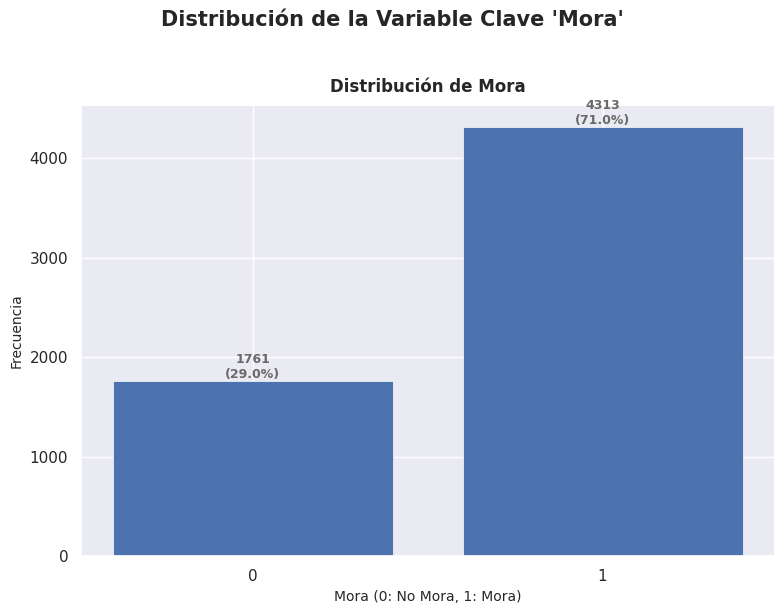

In [29]:
# distribución de variable clave

fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Adjusted to a single subplot

# Mora Distribution

counts_Mora = fraud_1['mora'].value_counts().sort_index() # Corrected to plot 'mora' and fixed syntax

bars = ax.bar(counts_Mora.index.astype(str), counts_Mora.values, edgecolor='white', linewidth=0.5) # Corrected bar plot call
for bar, n in zip(bars, counts_Mora.values):
    pct = n / len(fraud_1) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{n}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='dimgray')
ax.set_title('Distribución de Mora', fontsize=12, fontweight='bold', pad=10) # Updated title
ax.set_xlabel('Mora (0: No Mora, 1: Mora)', fontsize=10) # Updated xlabel
ax.set_ylabel('Frecuencia', fontsize=10)
sns.despine(ax=ax) # Corrected ax reference

plt.suptitle("Distribución de la Variable Clave 'Mora'", fontsize=15, fontweight="bold", y=1.02) # Updated suptitle
plt.tight_layout()
plt.show()

La Variable objetivo presenta una distribución sesgada:
* 71% de los casos son mora
* 29% son no mora

In [30]:
# Reduzco dataset para visualización

fraud_numeric = fraud_1.select_dtypes(include=["int64", "float64"])
fraud_numeric1 = fraud_numeric.drop(columns=['mora','atraso','nivel_educ_map','dias_lab', 'exp_sf', 'exp_sf_missing', 'linea_sf_missing', 'deuda_sf_missing'])

/tmp/ipykernel_39464/3105058249.py:67: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


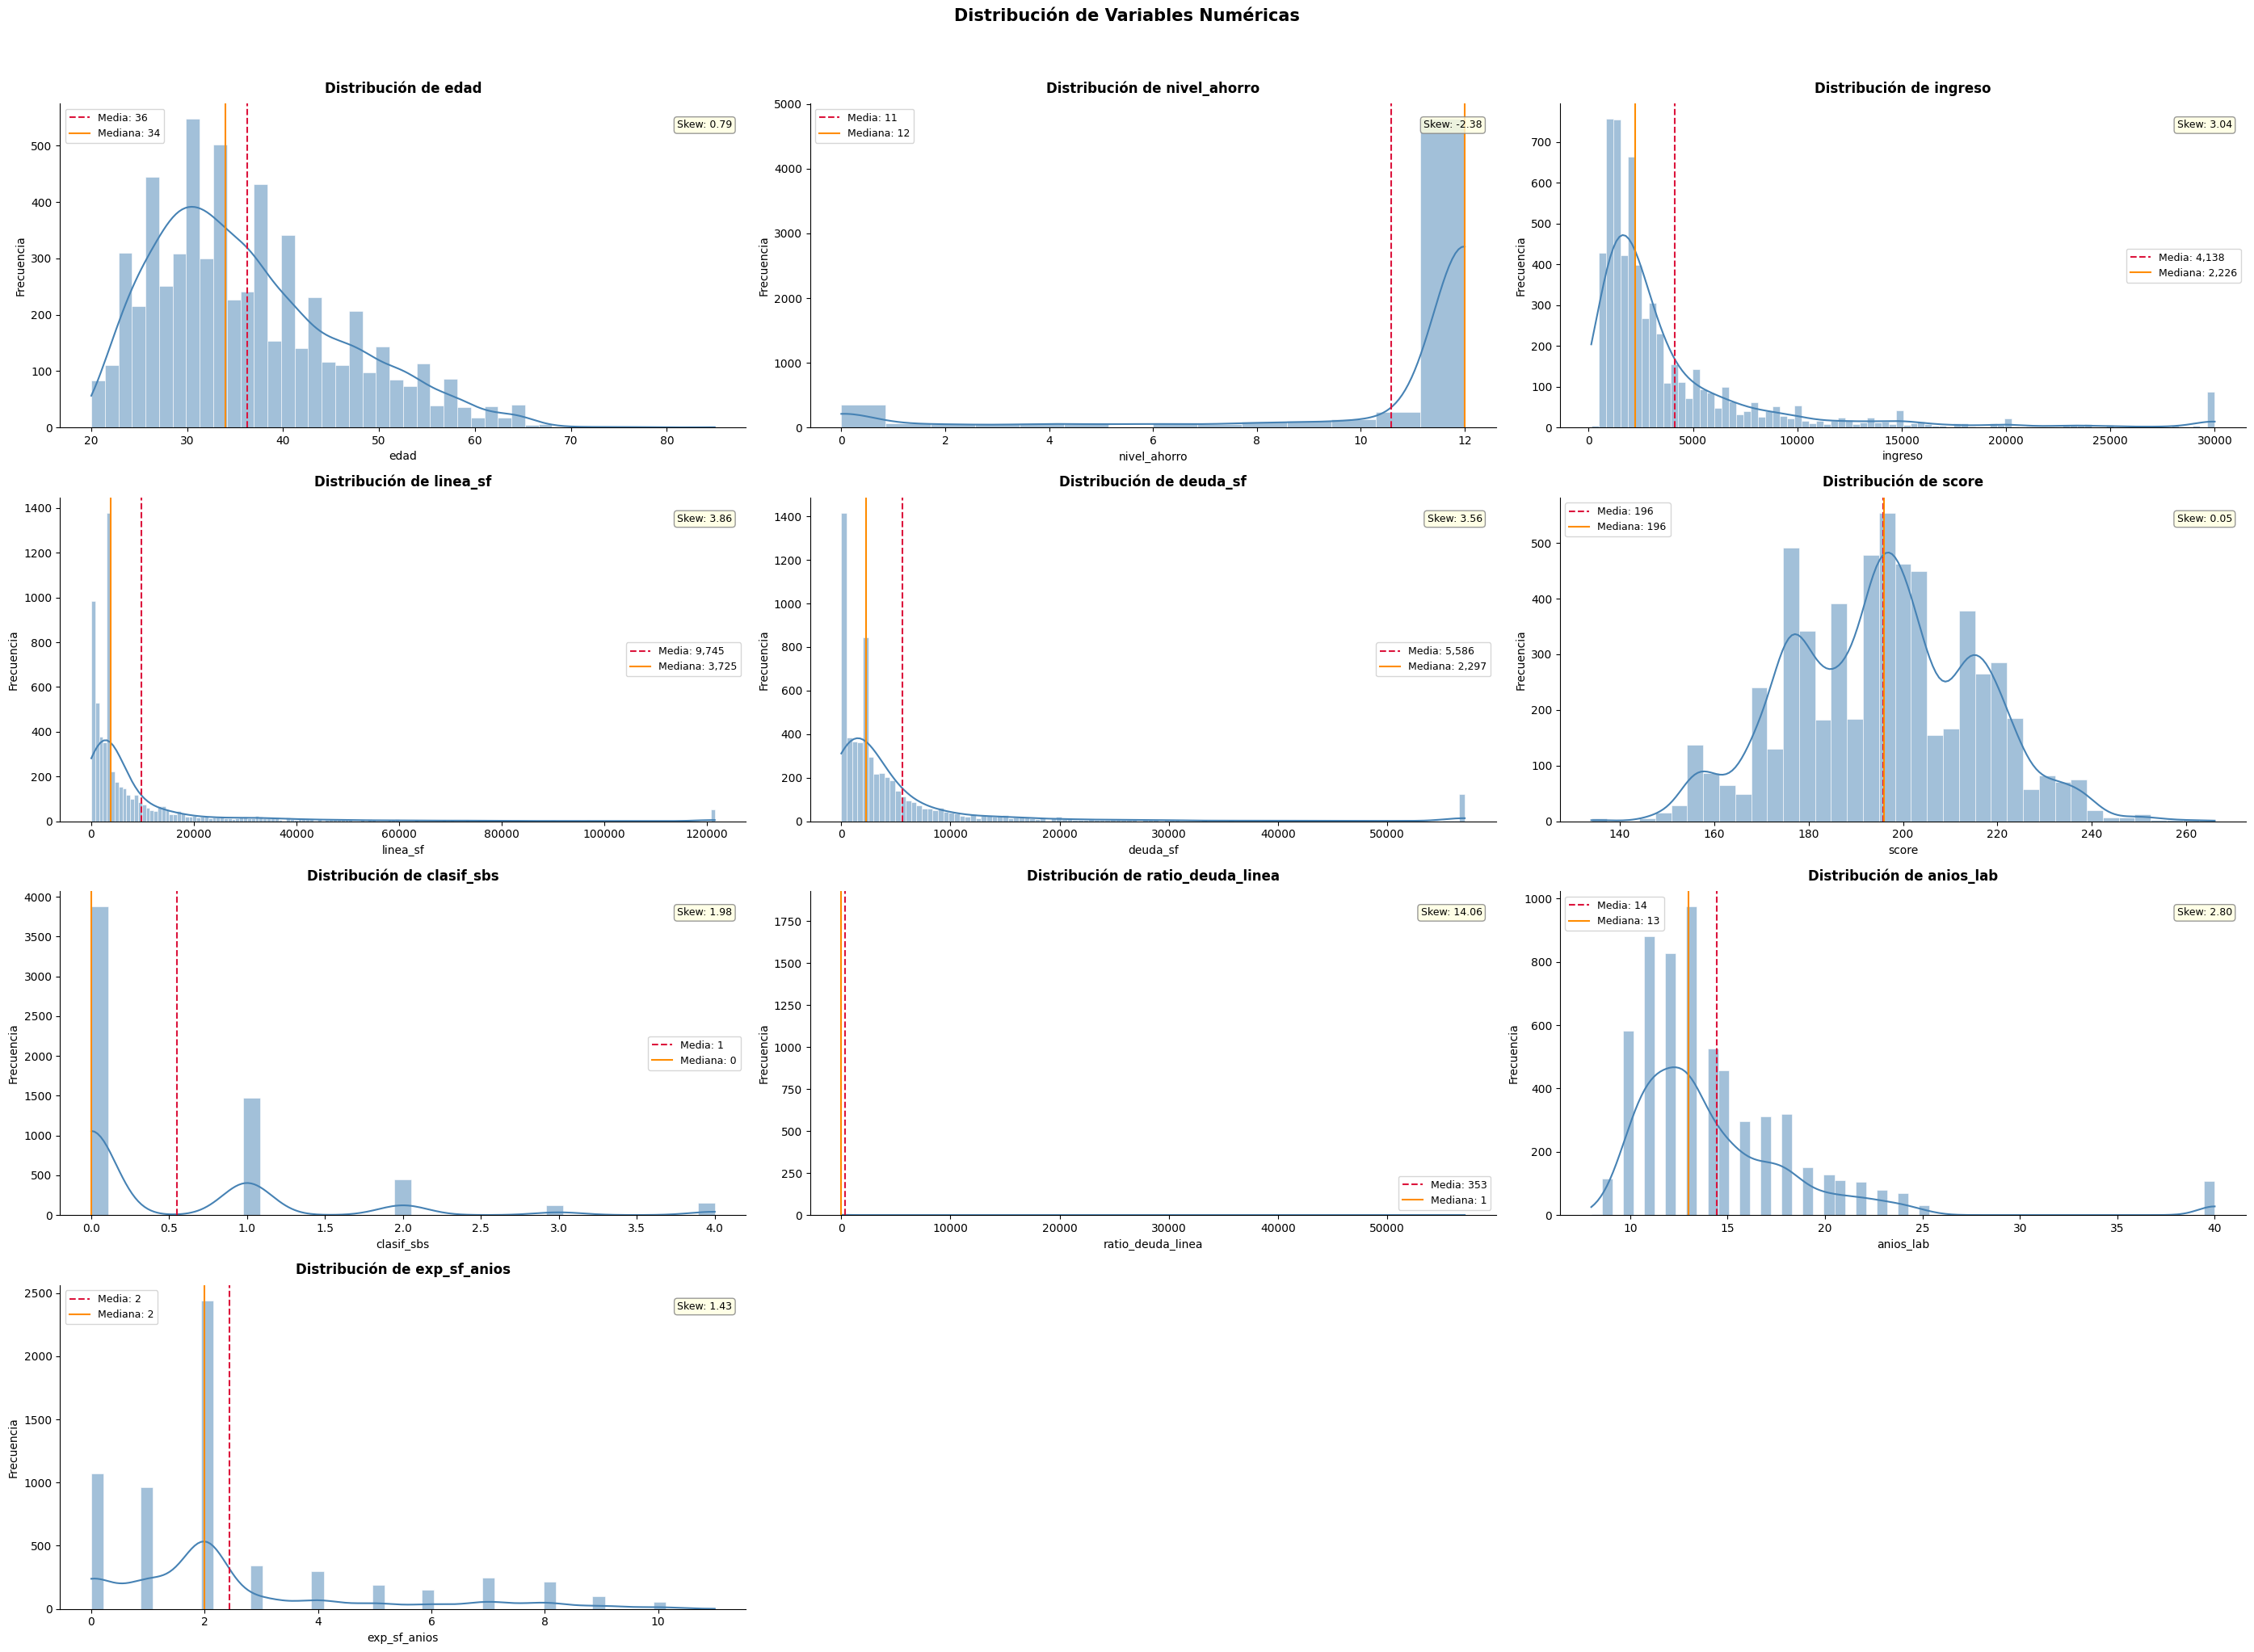

In [ ]:

# Configuración de grilla


n_cols = 3
n_rows = math.ceil(len(fraud_numeric1.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(fraud_numeric1.columns):
    sns.histplot(
        fraud_1[col].dropna(),
        kde=True,
        ax=axes[i],
        color="steelblue",
        edgecolor="white",
        linewidth=0.4
    )

    media = fraud_1[col].mean()
    mediana = fraud_1[col].median()
    skew = fraud_1[col].skew()

    axes[i].axvline(
        media,
        color="crimson",
        linestyle="--",
        linewidth=1.5,
        label=f"Media: {media:,.0f}"
    )

    axes[i].axvline(
        mediana,
        color="darkorange",
        linestyle="-",
        linewidth=1.5,
        label=f"Mediana: {mediana:,.0f}"
    )

    axes[i].set_title(f"Distribución de {col}", fontsize=12, fontweight="bold", pad=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frecuencia", fontsize=10)
    axes[i].legend(fontsize=9)

    axes[i].text(
        0.98, 0.95,
        f"Skew: {skew:.2f}",
        transform=axes[i].transAxes,
        fontsize=9,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="lightyellow",
            edgecolor="gray",
            alpha=0.8
        )
    )

    sns.despine(ax=axes[i])

# Eliminar gráficos vacíos si sobran ejes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Numéricas", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#***Insight***
| Variable | Interpretación |
|---|---|
| Edad | Distribución levemente asimétrica — media de 36 años y skew 0.79 |
| Nivel de ahorro | Variable categorica — los datos se concentran en 12 -gran capacidad de ahorro- y hay baja frecuencia en poca capacidad de ahorro. Es un dato llamativo y que contrasta con el alto nivel de mora |
| Ingresos |  Sesgo positivo y skew elevado-  muchos clientes con ingresos medios a bajos y pocos con altos ingresos |
| Linea sf | Sesgo positivo pronunciado y skew elevado — muchos créditos de bajo monto y pocos de alto monto |
| Deuda | Sesgo positivo pronunciado y skew elevado — muchos clientes sin deuda o con bajo monto de deuda y pocos con deudas elevadas|
| Score |  Distribución uniforme y skew cercano a 0 - El score se concentra en un umblar bajo, menor a 300 puntos|
| Clasificación |  Variable categorica - Los datos se concentran en buena clasificacion (0 y 1) y pocos con mala|
| Ratio Deuda | Sesgo altamente positivo - muchos datos cercanos a 0 y Skew muy alto (14). Hay outliers en 50.000|
| Años Laborales | Sesgo positivo - Media de 14 años y Skew 2.8|

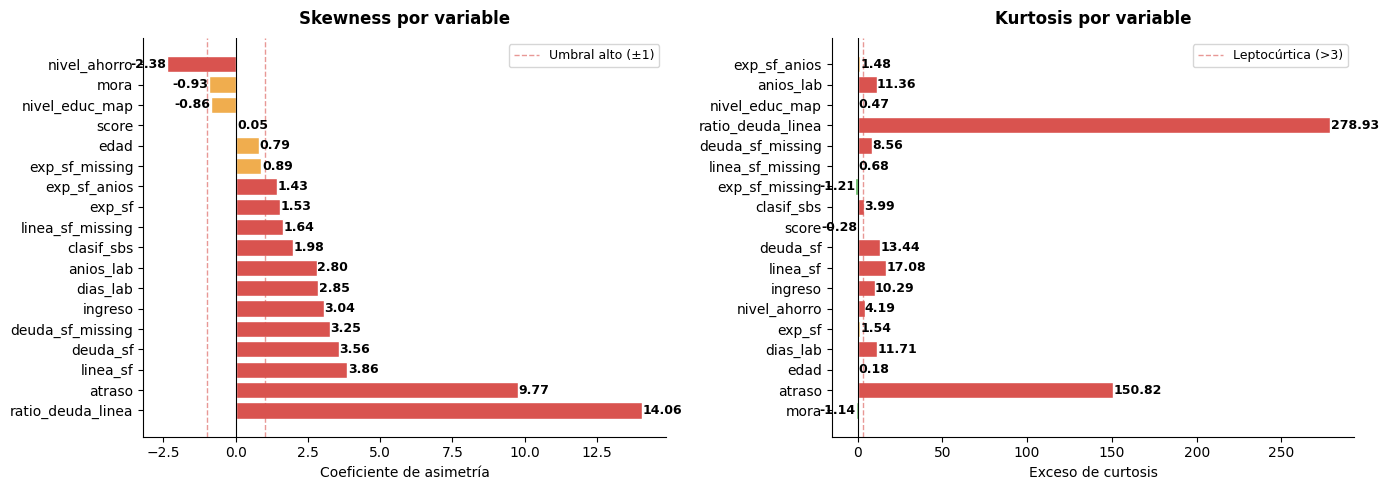

<Figure size 640x480 with 0 Axes>

In [ ]:
# Skewness y Kurtosis

skew_vals = fraud_1[fraud_numeric.columns].skew().sort_values(ascending=False)
kurt_vals = fraud_1[fraud_numeric.columns].kurtosis()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== SKEWNESS =====

colores_skew = [
    '#d9534f' if abs(v) > 1
    else '#f0ad4e' if abs(v) > 0.5
    else '#5cb85c'
    for v in skew_vals
]

bars = axes[0].barh(
    skew_vals.index,
    skew_vals.values,
    color=colores_skew,
    edgecolor='white'
)

axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(1, color='#d9534f', linewidth=1,
                linestyle='--', alpha=0.6,
                label='Umbral alto (±1)')
axes[0].axvline(-1, color='#d9534f',
                linewidth=1, linestyle='--', alpha=0.6)

for bar, val in zip(bars, skew_vals.values):
    axes[0].text(
        val + 0.02 if val >= 0 else val - 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
        fontweight='bold'
    )

axes[0].set_title('Skewness por variable',
                  fontsize=12, fontweight='bold', pad=10)

axes[0].set_xlabel('Coeficiente de asimetría', fontsize=10)
axes[0].legend(fontsize=9)

sns.despine(ax=axes[0])

# ===== KURTOSIS =====

colores_kurt = [
    '#d9534f' if v > 3
    else '#f0ad4e' if v > 1
    else '#5cb85c'
    for v in kurt_vals
]

bars2 = axes[1].barh(
    kurt_vals.index,
    kurt_vals.values,
    color=colores_kurt,
    edgecolor='white'
)

axes[1].axvline(0, color='black', linewidth=0.8)

axes[1].axvline(
    3,
    color='#d9534f',
    linewidth=1,
    linestyle='--',
    alpha=0.6,
    label='Leptocúrtica (>3)'
)

for bar, val in zip(bars2, kurt_vals.values):
    axes[1].text(
        val + 0.05 if val >= 0 else val - 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
        fontweight='bold'
    )

axes[1].set_title('Kurtosis por variable',
                  fontsize=12, fontweight='bold', pad=10)

axes[1].set_xlabel('Exceso de curtosis', fontsize=10)
axes[1].legend(fontsize=9)

sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

plt.suptitle('Forma de las Distribuciones — Skewness y Kurtosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

El analisis de skewness y Kurtosis evidencia:
- alta asimietria y colas pronunciadas en prácticamente todas las variables seleccionadas.
- Mayor asimetria (Skewness): Ratio deuda linea y atraso
- Mayor cola (Kurtosis): Ratio deuda y atraso

En conjunto, las variables númericas seleccionadas combinan concentración de datos y valores extremos

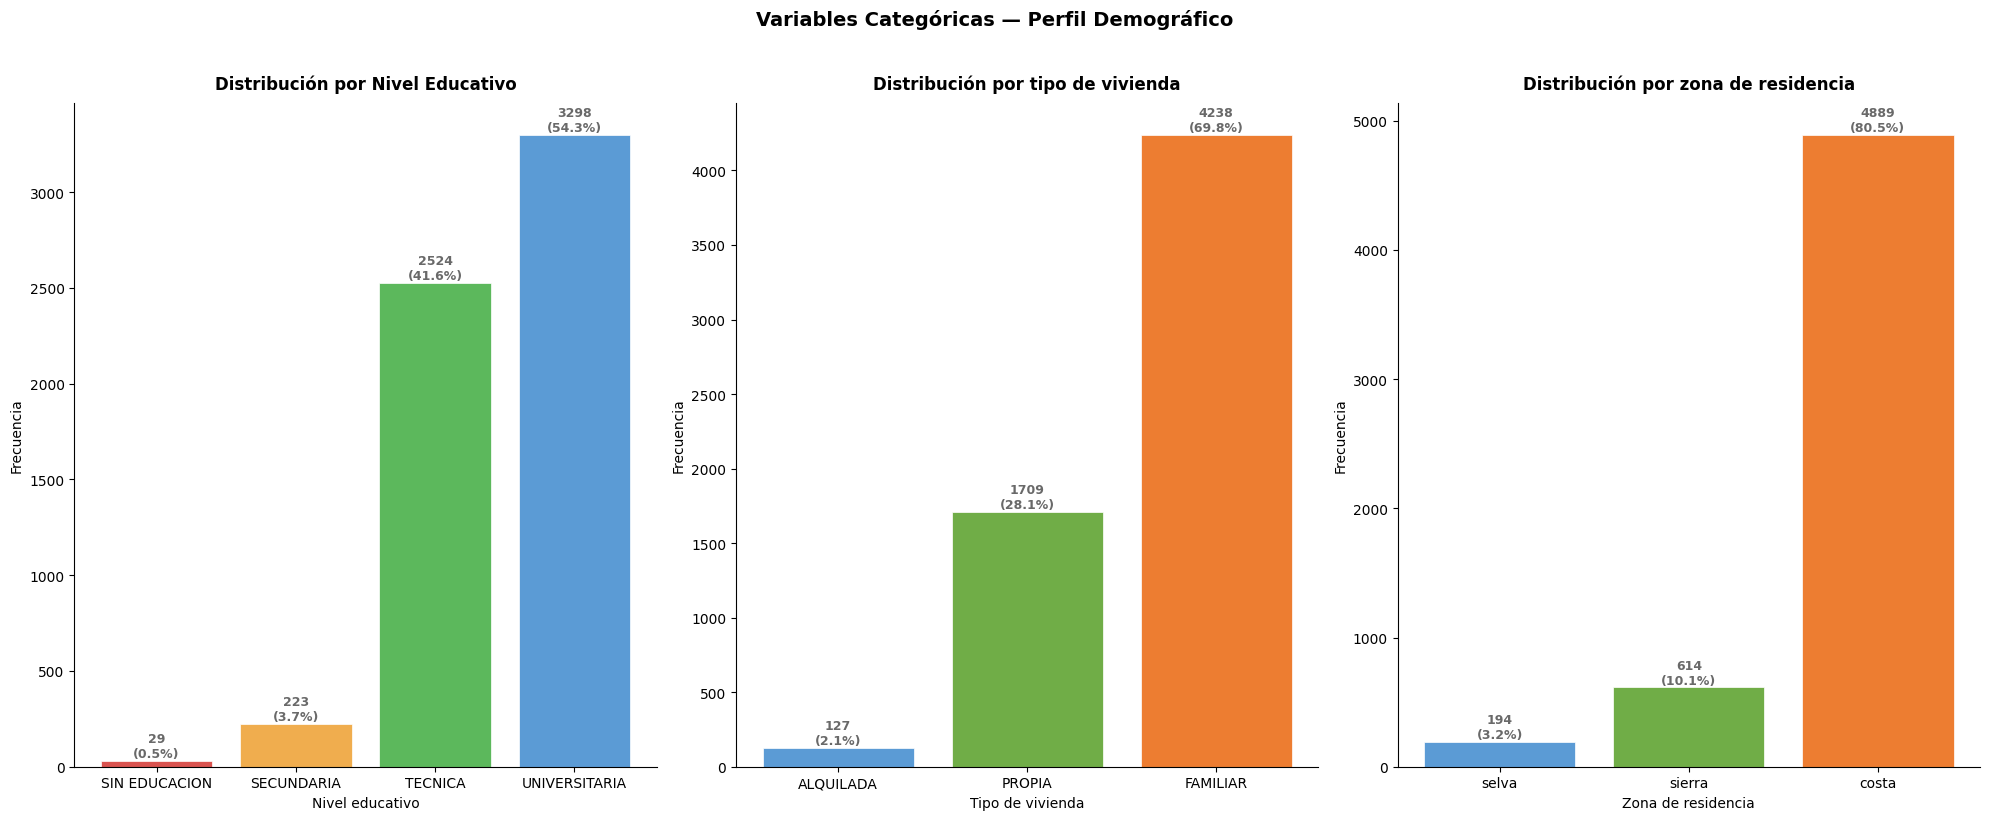

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Educación
orden_edu = ['SIN EDUCACION', 'SECUNDARIA', 'TECNICA', 'UNIVERSITARIA']
colores_edu = ['#d9534f', '#f0ad4e', '#5cb85c', '#5b9bd5']
counts_edu = fraud_1['nivel_educ'].value_counts().reindex(orden_edu, fill_value=0)
bars = axes[0].bar(orden_edu, counts_edu.values, color=colores_edu, edgecolor='white', linewidth=0.5)
for bar, n in zip(bars, counts_edu.values):
    pct = n / len(fraud_1) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{n}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='dimgray')
axes[0].set_title('Distribución por Nivel Educativo', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Nivel educativo', fontsize=10)
axes[0].set_ylabel('Frecuencia', fontsize=10)
sns.despine(ax=axes[0])


# Vivienda
orden_vivi = ['ALQUILADA', 'PROPIA', 'FAMILIAR']
colores_vivi = ['#5b9bd5', '#70ad47', '#ed7d31']
counts_vivi = fraud_1['vivienda'].value_counts().reindex(orden_vivi, fill_value=0)
bars2 = axes[1].bar(orden_vivi, counts_vivi.values, color=colores_vivi, edgecolor='white', linewidth=0.5)
for bar, n in zip(bars2, counts_vivi.values):
    pct = n / len(fraud_1) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{n}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='dimgray')
axes[1].set_title('Distribución por tipo de vivienda', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Tipo de vivienda', fontsize=10)
axes[1].set_ylabel('Frecuencia', fontsize=10)
sns.despine(ax=axes[1])


# Zona
# Zona
orden_zona = ['selva', 'sierra', 'costa']
colores_zona = ['#5b9bd5', '#70ad47', '#ed7d31']
counts_zona = fraud_1['zona_macro'].value_counts().reindex(orden_zona, fill_value=0)
bars2 = axes[2].bar(orden_zona, counts_zona.values, color=colores_zona, edgecolor='white', linewidth=0.5)
for bar, n in zip(bars2, counts_zona.values):
    pct = n / len(fraud_1) * 100
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{n}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='dimgray')
axes[2].set_title('Distribución por zona de residencia', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Zona de residencia', fontsize=10)
axes[2].set_ylabel('Frecuencia', fontsize=10)
sns.despine(ax=axes[2])


plt.suptitle('Variables Categóricas — Perfil Demográfico', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

***insight***

Las variables categoricas tipo objetc presentan una distribución asimetrica, particularmente en vivienda y zona de residencia


#*** Resúmen analisis univariado ***

- El analisis univariado observa que el dataset se encuentra desbalanceado.
- La mayoría de las variables analisadas poseen sesgo positivo.
- Los datos tienden a concentrarse y presentan colas extremas.

# ***EDA***

***Análisis bivariado***

In [ ]:
fraud_1.columns

Index(['mora', 'atraso', 'vivienda', 'edad', 'dias_lab', 'exp_sf',
       'nivel_ahorro', 'ingreso', 'linea_sf', 'deuda_sf', 'score', 'zona',
       'clasif_sbs', 'nivel_educ', 'exp_sf_missing', 'linea_sf_missing',
       'deuda_sf_missing', 'ratio_deuda_linea',
       'vivienda_desagregada_ALQUILADA', 'vivienda_desagregada_FAMILIAR',
       'vivienda_desagregada_PROPIA', 'educ_desagregada', 'nivel_educ_map',
       'zona_macro', 'zona_macro_desagregado_costa',
       'zona_macro_desagregado_selva', 'zona_macro_desagregado_sierra',
       'anios_lab', 'exp_sf_anios'],
      dtype='object')

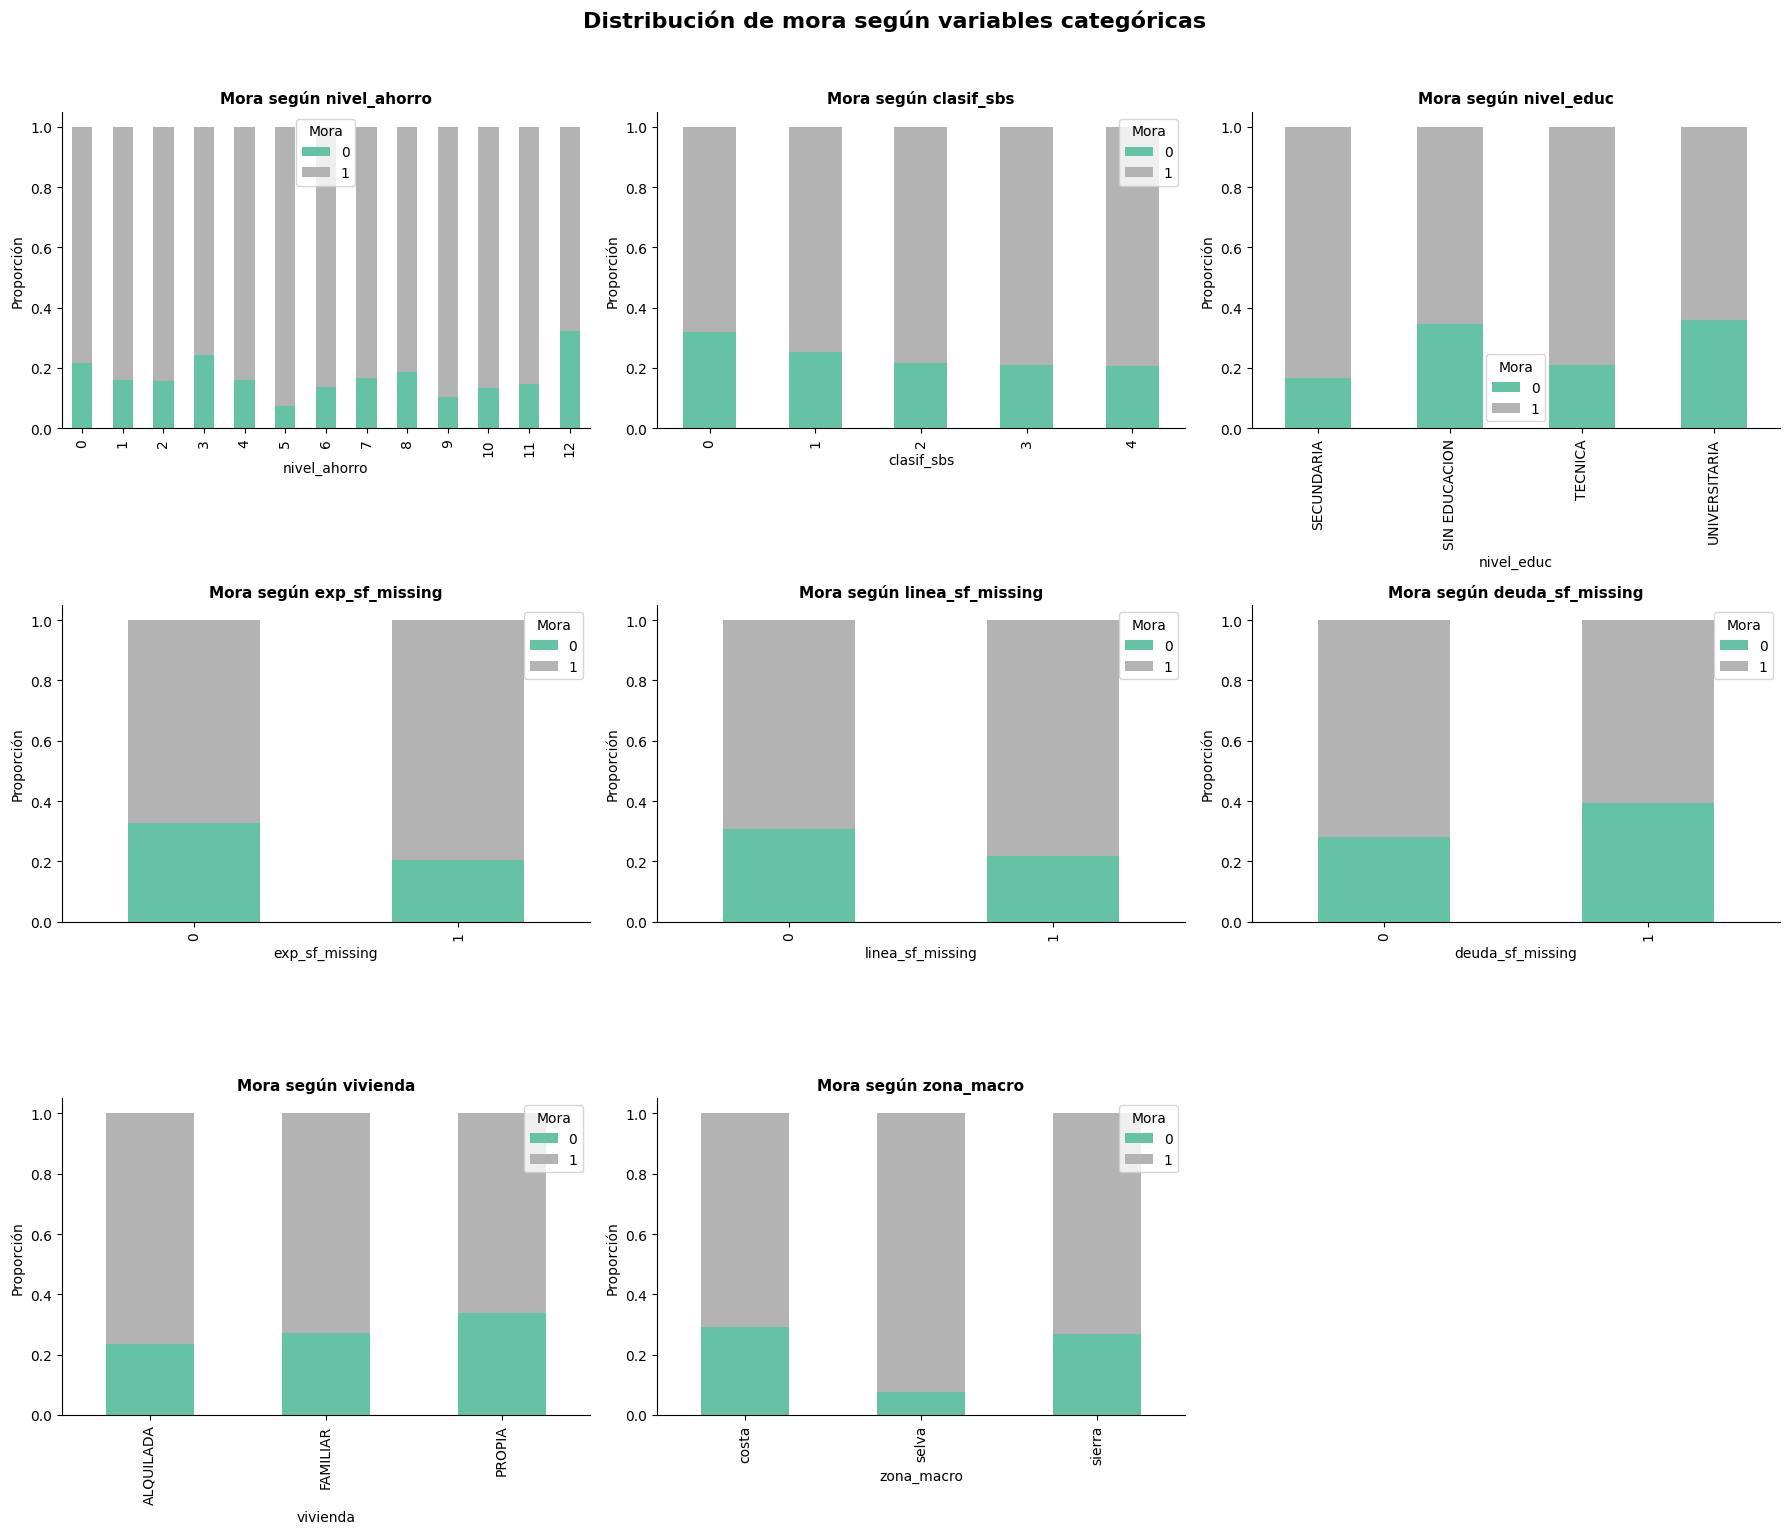

In [ ]:
variables_cat = [
    'nivel_ahorro',
    'clasif_sbs',
    'nivel_educ',
    'exp_sf_missing',
    'linea_sf_missing',
    'deuda_sf_missing',
    'vivienda',
    'zona_macro'
]

n_cols = 3
n_rows = math.ceil(len(variables_cat) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(variables_cat):

    tabla = pd.crosstab(
        fraud_1[col],
        fraud_1['mora'],
        normalize='index'
    )

    tabla.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        colormap='Set2'
    )

    axes[i].set_title(
        f'Mora según {col}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].set_ylabel('Proporción')

    axes[i].legend(title='Mora')

    sns.despine(ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Distribución de mora según variables categóricas',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

# ***insight***

Se observa que la mora tiende a ser más pronunciada en ciertos a perfiles crediticios que poseen:
- Peor nivel de clasificación
- Educación intermedia (secundaria y técnica)
- Vivienda Alquilada y Familiar
- En datos ausentes (exp_sf_missing y linea sf_missing)


Sin mora = 0
con Mora = 1
| variable | mayor casos con mora|
|---|---|
| Nivel de ahorro | 5 y 9 (niveles de ahorro medio y medio alto)|
| clasif_abs | 4 (peor clasificación) |
| nivel educativo | Secundaria y Educación técnica |
| exp_sf_missing | 1 (con datos  null) |
| línea_sf_missing| 1 (con datos null)|
| deuda_sf_missing| 0 (con dato no null)|
| vivienda | alquilada|
| zona | zona selva |


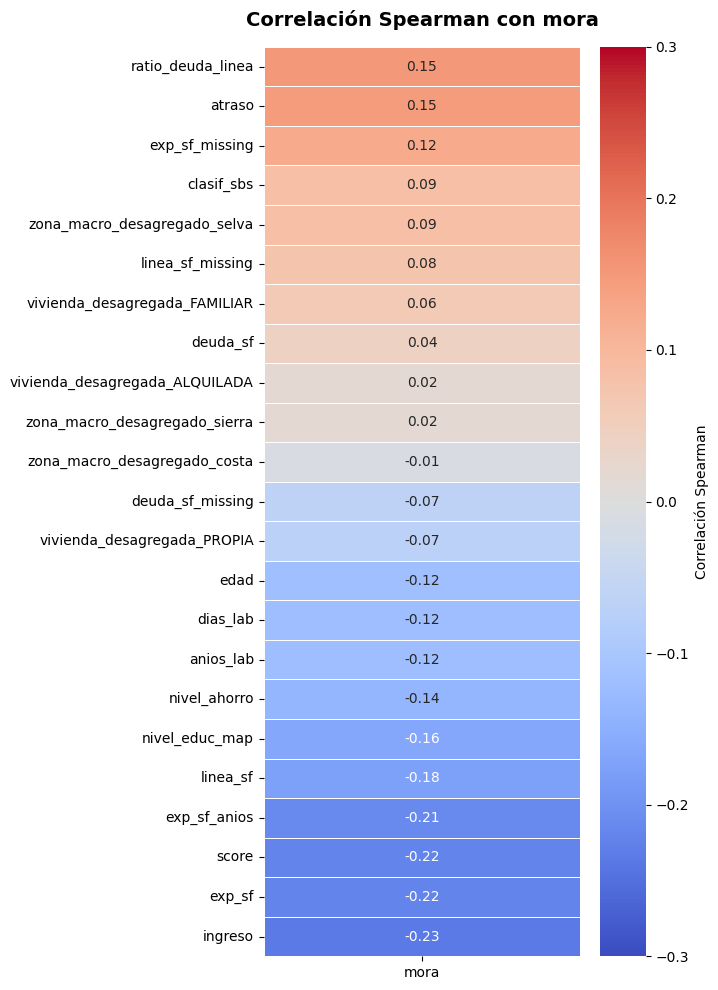

In [ ]:

# =========================
# Correlación Spearman con mora
# =========================

corr = fraud_1.corr(
    method='spearman',
    numeric_only=True
)[['mora']]

# eliminar autocorrelación mora = 1
corr = corr.drop(index='mora')

# ordenar correlaciones
corr = corr.sort_values(
    by='mora',
    ascending=False
)

# =========================
# Heatmap
# =========================

plt.figure(figsize=(7,10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-0.3,
    vmax=0.3,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlación Spearman'}
)

plt.title(
    'Correlación Spearman con mora',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

plt.tight_layout()

plt.show()

# ***INSIGHT***
No existe una correlación significativa entre mora y el resto de las variables del dataset que permita inferir una única variable explicativa de la mora.

- las variables de mayor correlación positiva son: ingreso, exp_sf, score, exp_sf_anios (equivalente a exp_sf) y linea sf
- Las variables de mayor correlación negativa son ratio_linea, atraso, exp_sf_missing y clasif_sbs

/tmp/ipykernel_39464/3511752213.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/3511752213.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/3511752213.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/3511752213.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


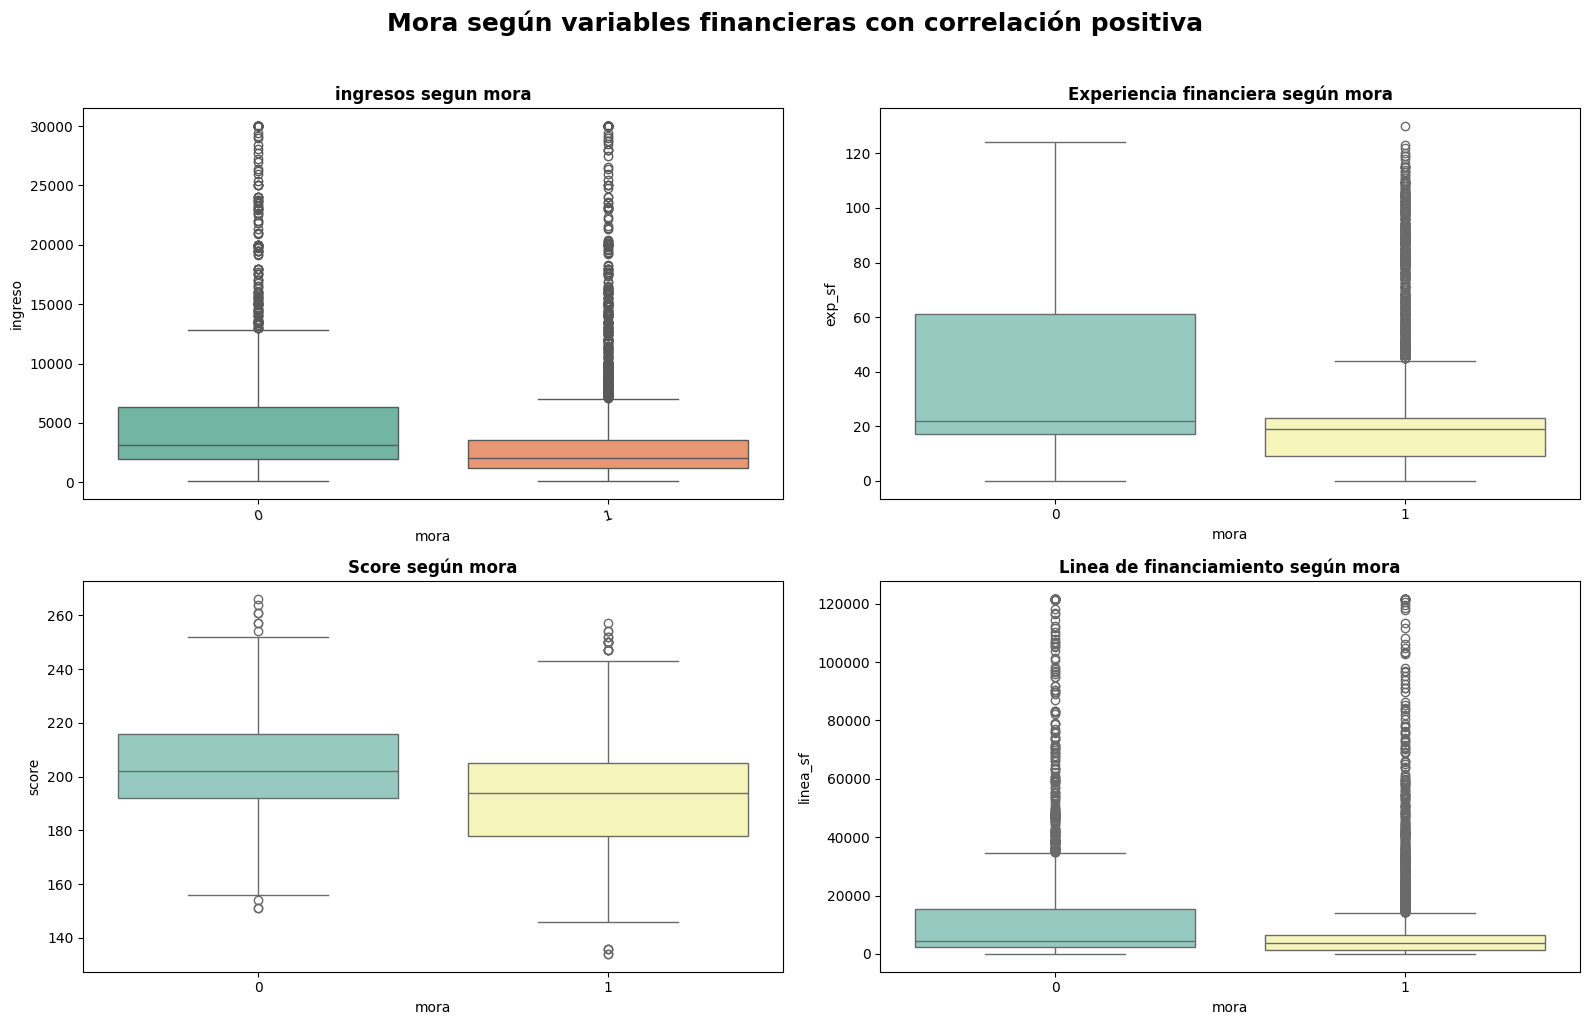

In [ ]:
# gráficos de boxplot: mora según variables financieras con correlación positiva

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
# =====  mora vs ingreso =====

sns.boxplot(
    data=fraud_1,
    x='mora',
    y='ingreso',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title(
    'ingresos segun mora',
    fontsize=12,
    fontweight='bold'
)

axes[0].tick_params(axis='x', rotation=15)

# ===== experiencia en sistema financiero vs mora =====

sns.boxplot(
    data=fraud_1,
    x='mora',
    y='exp_sf',
    palette='Set3',
    ax=axes[1]
)

axes[1].set_title(
    'Experiencia financiera según mora',
    fontsize=12,
    fontweight='bold'
)

# ===== Score vs mora =====

sns.boxplot(
    data=fraud_1,
    x='mora',
    y='score',
    palette='Set3',
    ax=axes[2]
)

axes[2].set_title(
    'Score según mora',
    fontsize=12,
    fontweight='bold'
)


# ===== Línea de financiamiento vs mora =====

sns.boxplot(
    data=fraud_1,
    x='mora',
    y='linea_sf',
    palette='Set3',
    ax=axes[3]
)

axes[3].set_title(
    'Linea de financiamiento según mora',
    fontsize=12,
    fontweight='bold'
)


plt.suptitle(
    'Mora según variables financieras con correlación positiva',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

***Insight***

Al profundizar el hallazgo del heatmap mediante un boxplot observamos como varian medidas de tendencia central en mora y no mora:

1. Los ingresos suelen ser menores en clientes morosos
2. Los clientes con menor expriencia financiera son más morosos
3. Los clietes con Score más baja tienen mayor mora
4. clientes morosos tienen líneas de financiamiento menor, aunque predominan gran número de outliers

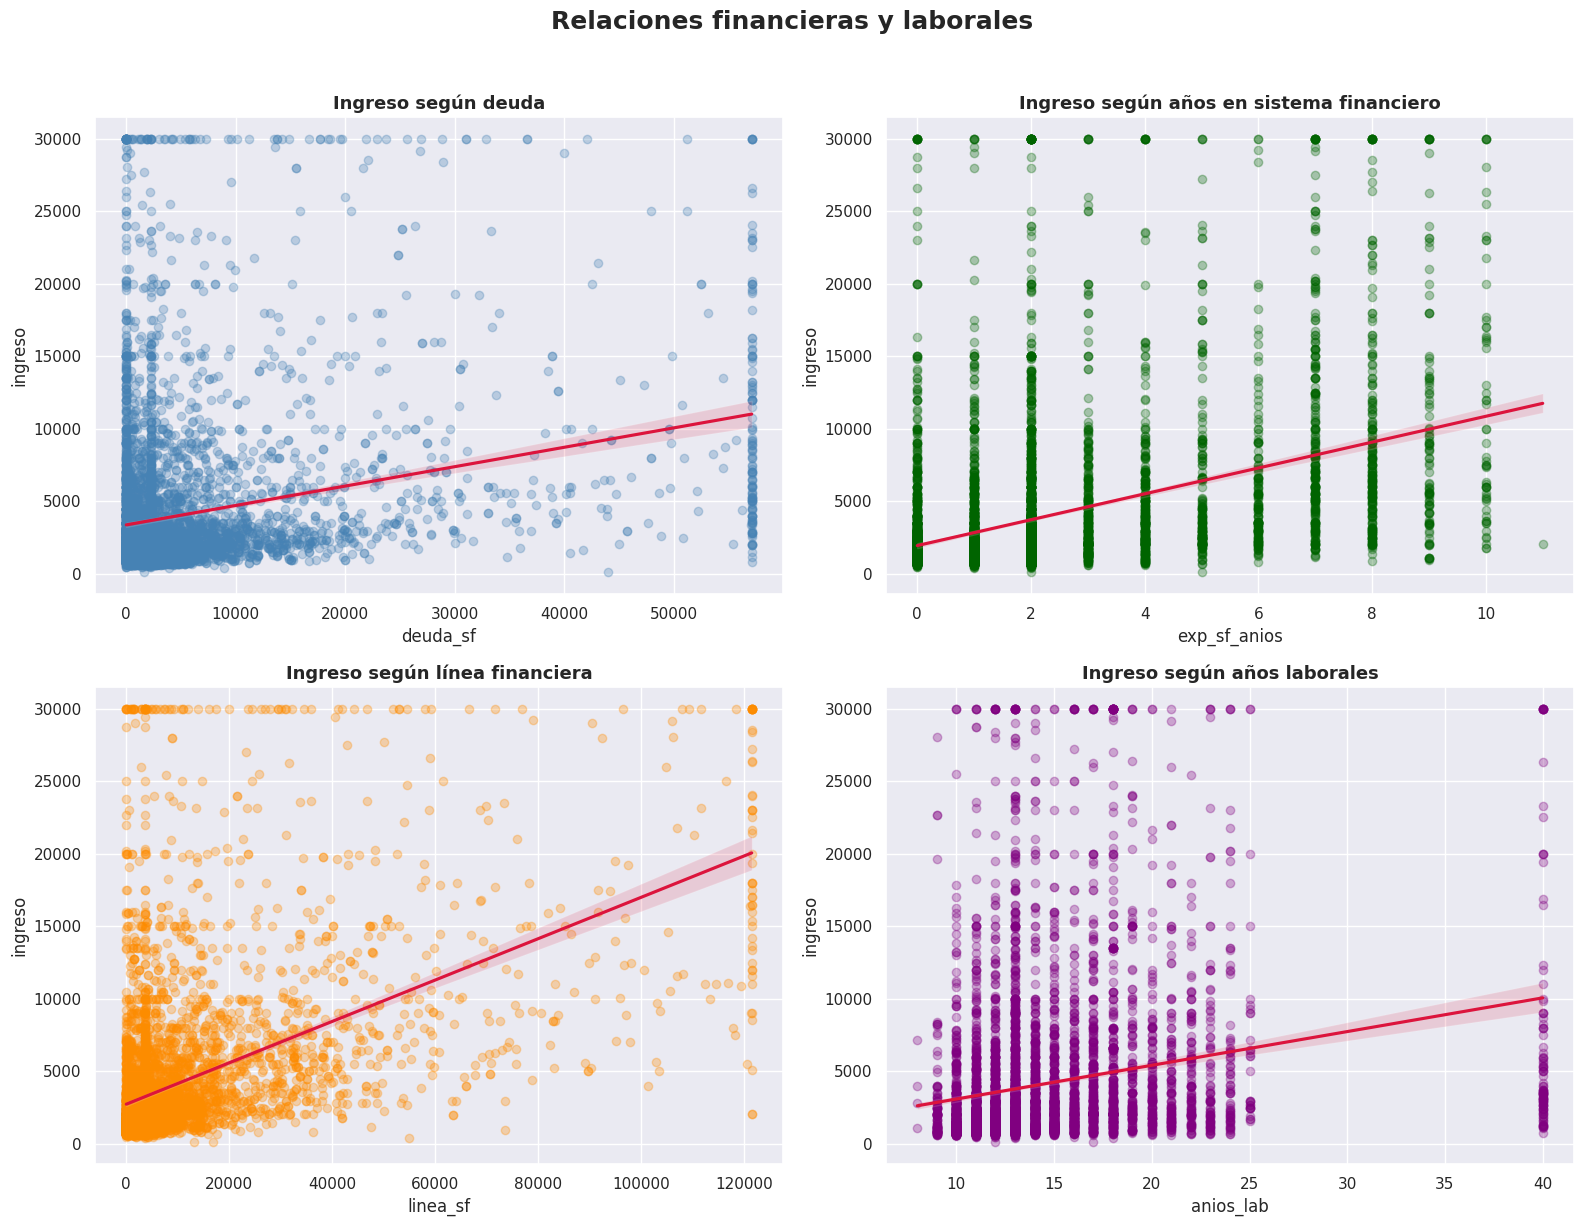

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ===== ingreso vs deuda =====

sns.regplot(
    data=fraud_1,
    x='deuda_sf',
    y='ingreso',
    scatter_kws={'alpha':0.3, 'color':'steelblue'},
    line_kws={'color':'crimson'},
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Ingreso según deuda',
    fontsize=13,
    fontweight='bold'
)

# ===== ingreso vs experiencia sistema financiero =====

sns.regplot(
    data=fraud_1,
    x='exp_sf_anios',
    y='ingreso',
    scatter_kws={'alpha':0.3, 'color':'darkgreen'},
    line_kws={'color':'crimson'},
    ax=axes[0,1]
)

axes[0,1].set_title(
    'Ingreso según años en sistema financiero',
    fontsize=13,
    fontweight='bold'
)

# ===== ingreso vs línea =====

sns.regplot(
    data=fraud_1,
    x='linea_sf',
    y='ingreso',
    scatter_kws={'alpha':0.3, 'color':'darkorange'},
    line_kws={'color':'crimson'},
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Ingreso según línea financiera',
    fontsize=13,
    fontweight='bold'
)

# ===== ingreso vs años laborales =====

sns.regplot(
    data=fraud_1,
    x='anios_lab',
    y='ingreso',
    scatter_kws={'alpha':0.3, 'color':'purple'},
    line_kws={'color':'crimson'},
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Ingreso según años laborales',
    fontsize=13,
    fontweight='bold'
)

plt.suptitle(
    'Relaciones financieras y laborales',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

***Insight ingresos según variables financieras seleccionadas***

Relación ingreso con variables seleccionadas (deuda, exp_sf_anios, línea financiera y años laborales)

Si bien la mayoria de los clientes posee ingresos de medios a bajos, observamos que su distribución no es homogénea en las variables seleccionadas.
|variable | Insight |
|---|---|
| Ingreso según deuda | Ingresos y Deuda suelen concentrarse en montos bajos y tienden a crecer linealmente, aunque existen casos extremos(ingresos bajos y deuda alta y deuda baja con ingresos altos) |
| ingresos según años en sistema| Los ingresos menores tienden a concentrarse en menores años en el sistema y la tendencia es que crezcan juntos, aunque existen casos extremos (poca experiencia con altos ingresos y mucha experiencia con bajos ingresos)|
| ingresos según línea financiera| la financiación crece según los ingresos, aunque la mayoría de las líneas financieras corresponden a clientes de ingresos bajos|
|Ingresos según años lab | los ingresos tienden a crecer según los años de trabajo|

/tmp/ipykernel_39464/2975680954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/2975680954.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/2975680954.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


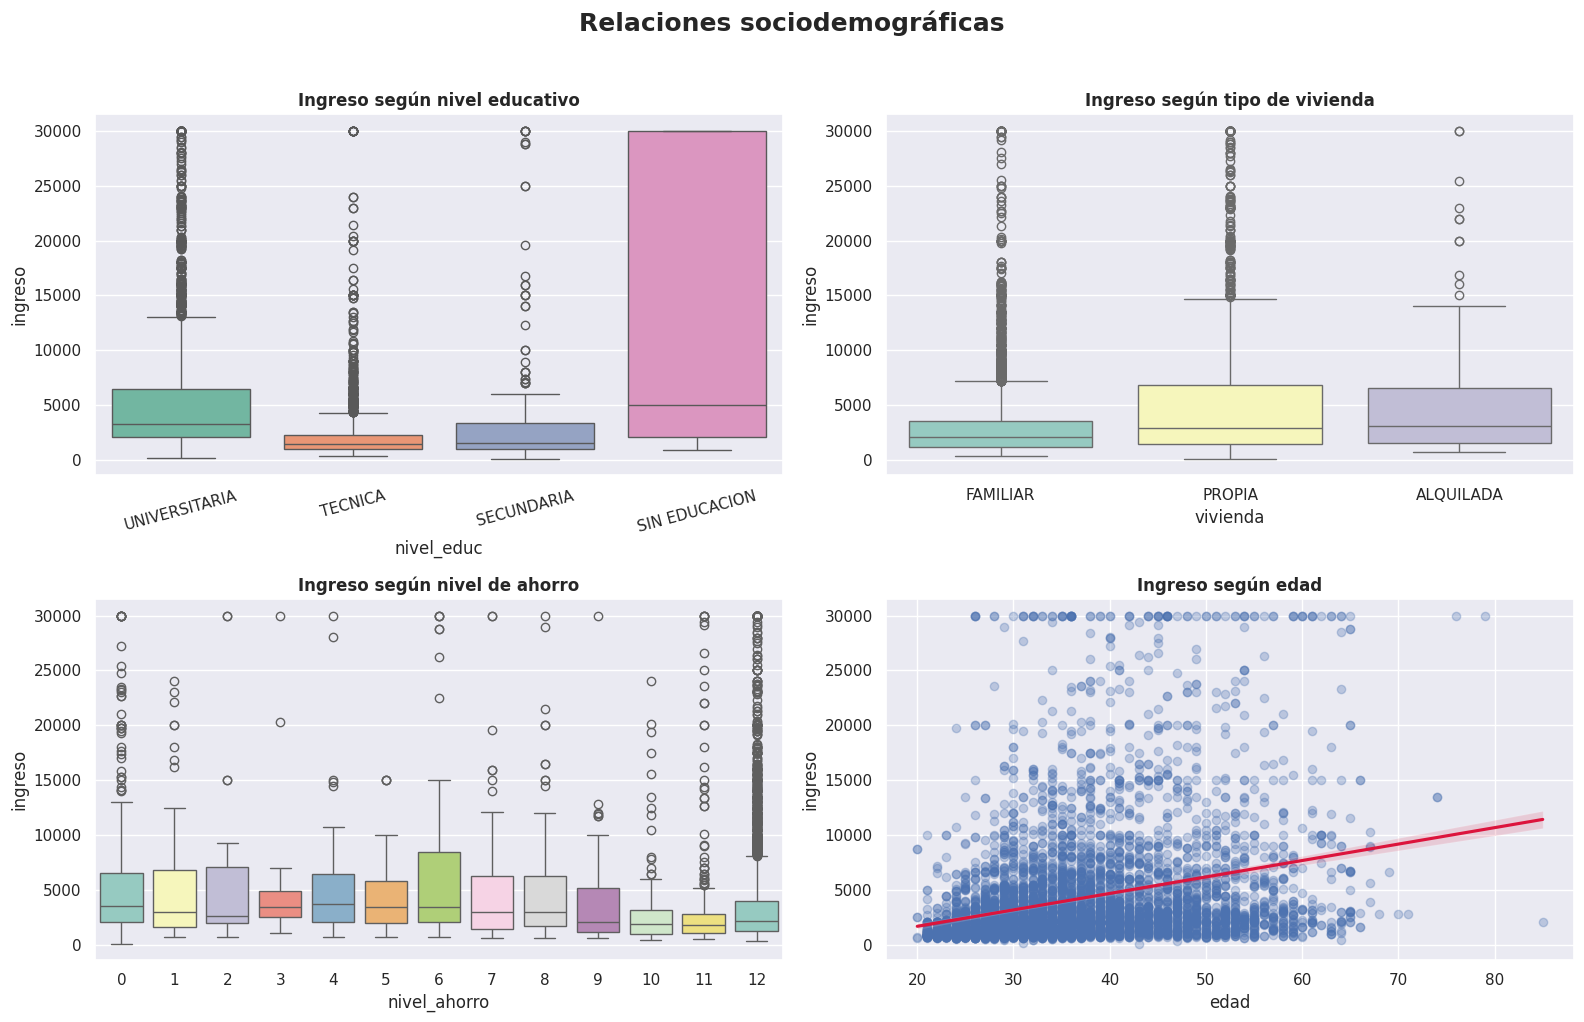

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
# ===== ingreso vs educación =====

sns.boxplot(
    data=fraud_1,
    x='nivel_educ',
    y='ingreso',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title(
    'Ingreso según nivel educativo',
    fontsize=12,
    fontweight='bold'
)

axes[0].tick_params(axis='x', rotation=15)

# ===== ingreso vs vivienda =====

sns.boxplot(
    data=fraud_1,
    x='vivienda',
    y='ingreso',
    palette='Set3',
    ax=axes[1]
)

axes[1].set_title(
    'Ingreso según tipo de vivienda',
    fontsize=12,
    fontweight='bold'
)

# ===== ingreso vs nivel de ahorro =====

sns.boxplot(
    data=fraud_1,
    x='nivel_ahorro',
    y='ingreso',
    palette='Set3',
    ax=axes[2]
)

axes[2].set_title(
    'Ingreso según nivel de ahorro',
    fontsize=12,
    fontweight='bold'
)


# ===== ingreso vs edad =====

sns.regplot(
    data=fraud_1,
    x='edad',
    y='ingreso',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'crimson'},
    ax=axes[3]
)

axes[3].set_title(
    'Ingreso según edad',
    fontsize=12,
    fontweight='bold'
)

plt.suptitle(
    'Relaciones sociodemográficas',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

***Insight ingresos según variables sociodemográficas***
Si bien la mayoria de los clientes posee ingresos de medios a bajos, observamos que su distribución no es homogénea en las variables seleccionadas.
|variable | Insight |
|---|---|
| Ingreso según nivel educativo | Los universitarios concentran los mayores ingresos, seguida por la secundaria y la técnica Es llamativo que la técnica tenga una mediana menor, aunque posee muchos outliers. Hay una anomalía en "sin educación" que rompe el patrón del boxplot |
| ingresos según vivienda| vivienda propia posee mayores ingresos y familiar los menores|
| ingresos según nivel de ahorro| los boxplot son dispares, no se observa una correspondencia clara entre nivel de ingreso y ahorro|
|Ingresos según edad | los ingresos tienden a crecer moderadamente según la edad del cliente y ser mayores entre los 40 y 50 años|

In [ ]:
print("analizamos si la anomalia de sin educación corresponde a datos ausentes")
print("")
print(fraud_1['nivel_educ'].value_counts())
print("")
print("son pocos casos, pero resultan sospechosos. Se transforman a -sin informacion-")
print("")
fraud_1['nivel_educ'] = fraud_1['nivel_educ'].replace(
    'SIN EDUCACION',
    'NO INFORMADO'
)
print("")
print(fraud_1['nivel_educ'].value_counts())

analizamos si la anomalia de sin educación corresponde a datos ausentes

nivel_educ
UNIVERSITARIA    3298
TECNICA          2524
SECUNDARIA        223
SIN EDUCACION      29
Name: count, dtype: int64

son pocos casos, pero resultan sospechosos. Se transforman a -sin informacion-


nivel_educ
UNIVERSITARIA    3298
TECNICA          2524
SECUNDARIA        223
NO INFORMADO       29
Name: count, dtype: int64


Text(0.5, 1.0, 'Score según clasificación')

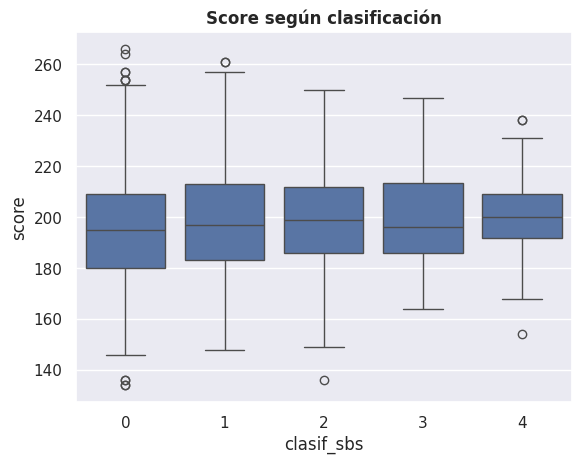

In [ ]:
ax = sns.boxplot(
    data=fraud_1,
    x='clasif_sbs',
    y='score'
)

ax.set_title(
    'Score según clasificación',
    fontsize=12,
    fontweight='bold'
)

#Mientras mayor es el score, mejor perfil crediticio tiene el cliente

#Clasif_sbs: Clasificación SBS. Mientras mayor es el número, peor clasificación tiene el cliente: {0: normal, 1: con problemas potenciales, 2: deficiente, 3: dudoso, 4: pérdida}

***insight***

- No se visualiza una correlación significativa entre score y clasificación.
- Los menjores clientes (0 y 1) y los peores (3 y 4) -considerados "perdida"- comparten una mediana similar.
- Se esperaría en esta visualización que los box compongan una diagonal descendente hacía la derecha que muestre mayor score en mejores clientes y peor score en peores clientes.
- Esta visualización interroga acerca de la imputación de score y clasificación bancaria

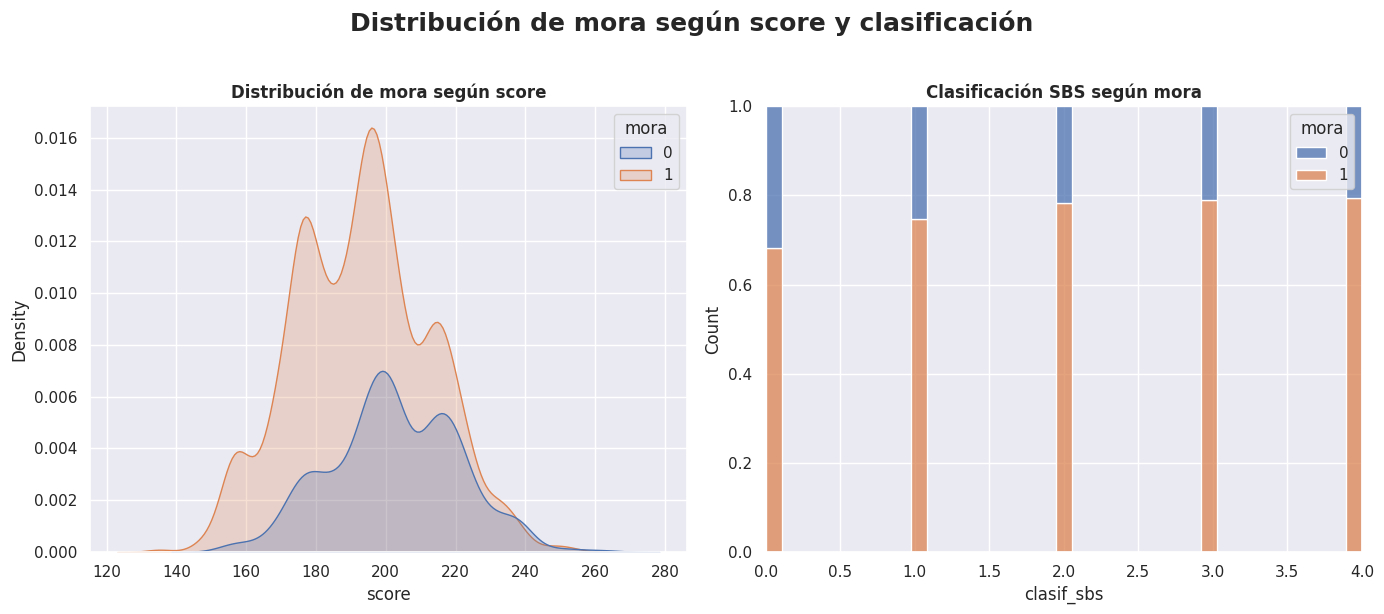

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== score =====

sns.kdeplot(
    data=fraud_1,
    x='score',
    hue='mora',
    fill=True,
    ax=axes[0]
)

axes[0].set_title(
    'Distribución de mora según score',
    fontsize=12,
    fontweight='bold'
)

# ===== clasificacion SBS =====

sns.histplot(
    data=fraud_1,
    x='clasif_sbs',
    hue='mora',
    multiple='fill'
)


axes[1].set_title(
    'Clasificación SBS según mora',
    fontsize=12,
    fontweight='bold'
)

plt.suptitle(
    'Distribución de mora según score y clasificación',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


***Insight***

- Se presentan mayor concentración de casos con mora en scores bajos
- La mora es mayor entre los clientes peor clasificados.
- No obstante, se encuentra una mora elevada en todos los niveles de clasificación y de score, aunque en este último caso en menor medida


#***analisis multivariado***


***Perfíl crediticio de los clientes***

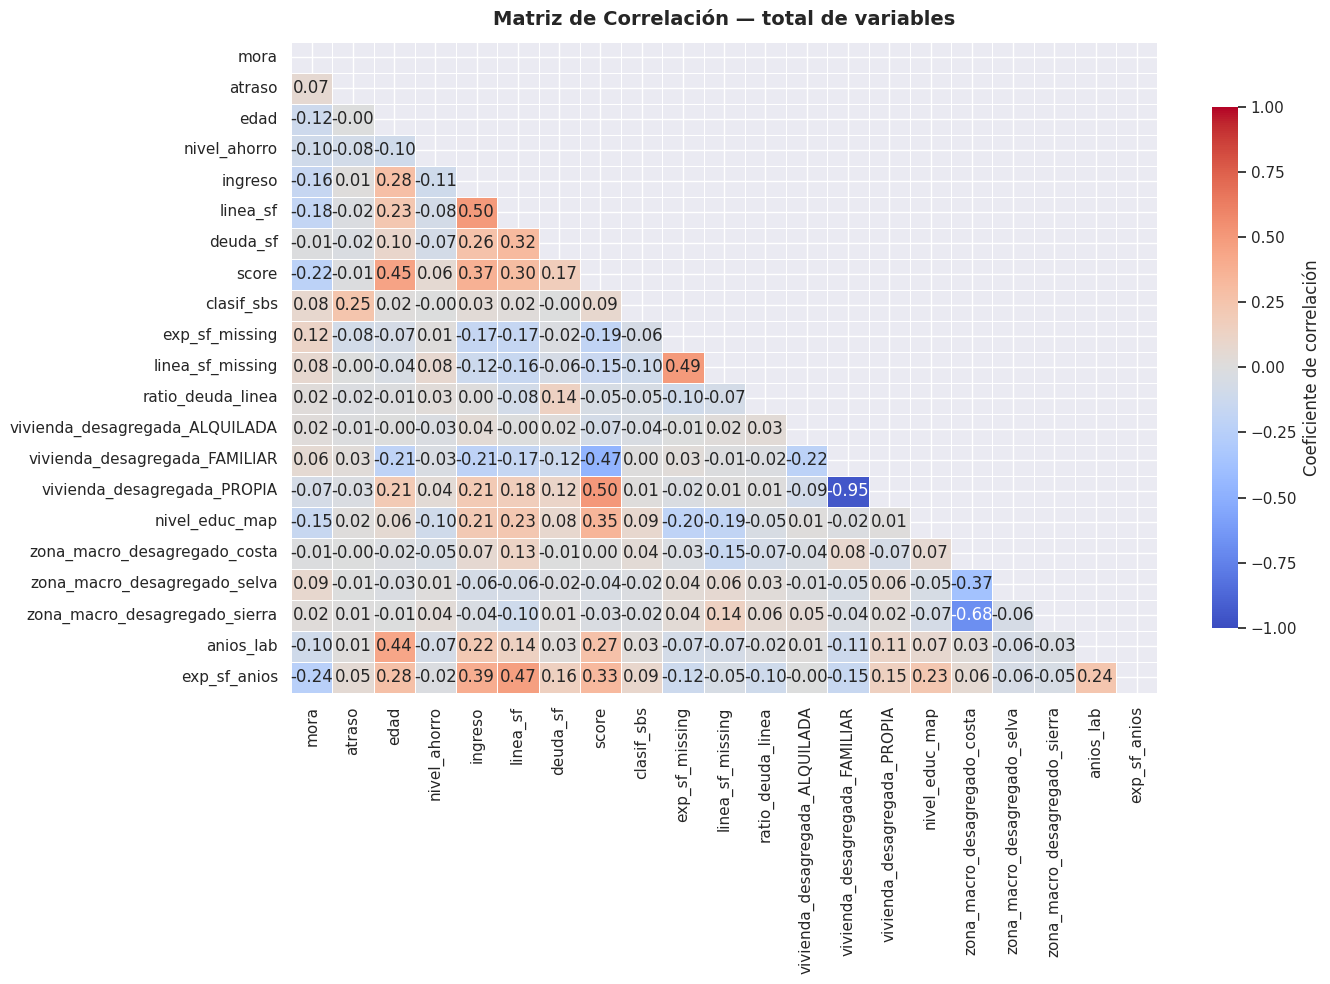

In [ ]:
# Matriz de correlación
vars_corr = ['mora', 'atraso', 'edad',
       'nivel_ahorro', 'ingreso', 'linea_sf', 'deuda_sf', 'score',
       'clasif_sbs', 'exp_sf_missing', 'linea_sf_missing', 'ratio_deuda_linea',
       'vivienda_desagregada_ALQUILADA', 'vivienda_desagregada_FAMILIAR',
       'vivienda_desagregada_PROPIA', 'nivel_educ_map','zona_macro_desagregado_costa',
       'zona_macro_desagregado_selva', 'zona_macro_desagregado_sierra',
       'anios_lab', 'exp_sf_anios']

corr = fraud_1[vars_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'})
ax.set_title('Matriz de Correlación — total de variables', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()



Si bien la variable objetivo presenta una correlación baja con el conjunto de las variables, al intereior del dataset existen variables de mayor correlación:

* En este caso, Score una variable que mide el puntaje del cliente se correlaciona con experiencia en el sistema financierto, años laborales, nivel educativo y vivienda propia
* Por su parte, la clasificación del cliente encuentra mayor correlación con retraso.

* Este hallazgo podría indicar que la clasificación y el score se basan principalmente en las variables que presentan mayor correlación

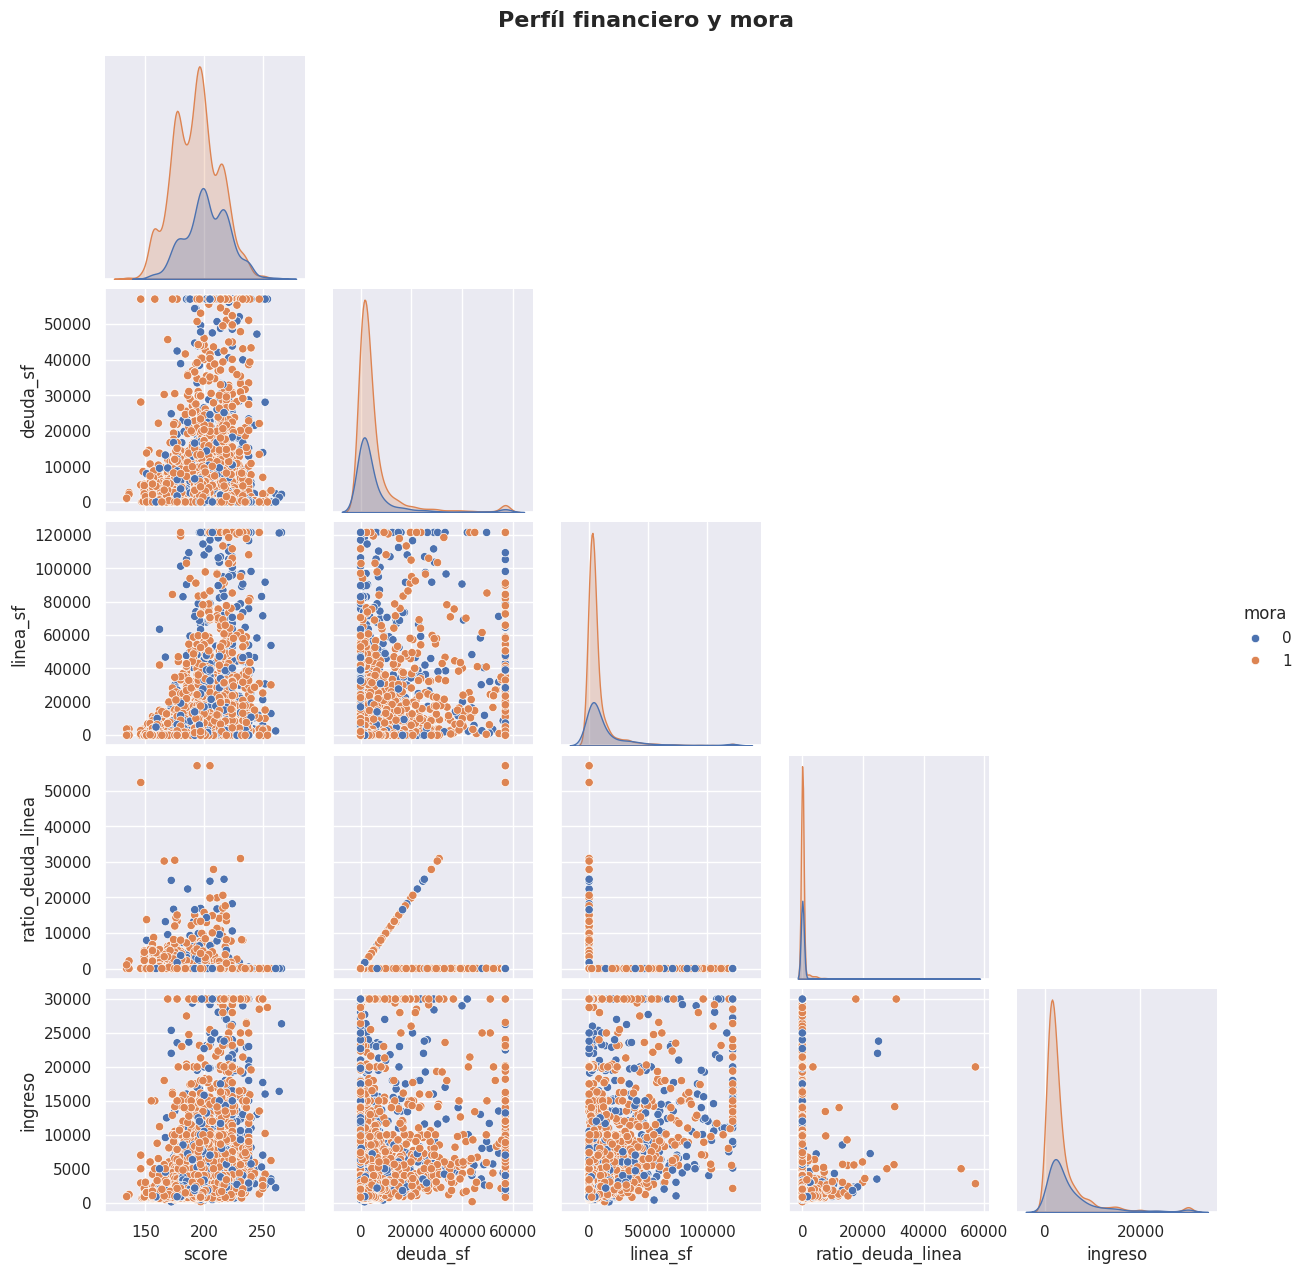

In [ ]:
vars_financieras = [
    'score',
    'deuda_sf',
    'linea_sf',
    'ratio_deuda_linea',
    'ingreso'
]

g = sns.pairplot(
    fraud_1[vars_financieras + ['mora']],
    hue='mora',
    diag_kind='kde',
    corner=True
)

# título general
g.fig.suptitle(
    'Perfíl financiero y mora',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.show()

La visualización de multiples gráficos que correlacionan variables financieras con mora no permite detectar una separación visual entre mora y no mora.

Esta singularidad presupone la necesidad de desarrollar un modelo de aprendizaje supervisado que detecte relaciones complejas entre los datos

#***Preparación de modelos de clasificación***

* En esta sección preparamos dos modelos de clasificación: Regresión logistica y Random Forest

* Mediante técnicas de valifación cruzada se determina qué modelo presenta mejor desempeño.

* Se mejora el rendimiento del modelo ajustando los parametros con RandomizedSearchCV

* Se evalua el desempeño del modelo con distintos metricas: classificator repor, matriz de confusión, ROC-AUC, PR-AUC, Cohen Kappa, MCC, Balanced Accuaracy

* Se analizan importancias

* Se crean visualizaciones

In [ ]:
fraud_1.columns

Index(['mora', 'atraso', 'vivienda', 'edad', 'dias_lab', 'exp_sf',
       'nivel_ahorro', 'ingreso', 'linea_sf', 'deuda_sf', 'score', 'zona',
       'clasif_sbs', 'nivel_educ', 'exp_sf_missing', 'linea_sf_missing',
       'deuda_sf_missing', 'ratio_deuda_linea',
       'vivienda_desagregada_ALQUILADA', 'vivienda_desagregada_FAMILIAR',
       'vivienda_desagregada_PROPIA', 'educ_desagregada', 'nivel_educ_map',
       'zona_macro', 'zona_macro_desagregado_costa',
       'zona_macro_desagregado_selva', 'zona_macro_desagregado_sierra',
       'anios_lab', 'exp_sf_anios'],
      dtype='object')

In [ ]:
#define variables predictora  y ("mora") y variables x -eliminando columnas que repiten información--

y = fraud_1['mora']
X = fraud_1.drop(['mora', 'vivienda', 'dias_lab', 'zona', 'exp_sf', 'nivel_educ', 'educ_desagregada', 'zona_macro'], axis=1)

X = X.astype(float)

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

#train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X = X.astype(float)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

scores_log = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression F1 CV:", scores_log.mean())

Logistic Regression F1 CV: 0.7501556084352573


In [ ]:
#aplico algoritmo de clasificación random foresta
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)


In [ ]:
#validacíón cruzada
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Random Forest F1 CV:", scores_rf.mean())

Random Forest F1 CV: 0.843202369296095


In [ ]:
#Entreno ambos modelos

log_model.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
print("Logistic Regression F1 CV:", scores_log.mean())
print("Random Forest F1 CV:", scores_rf.mean())

Logistic Regression F1 CV: 0.7501556084352573
Random Forest F1 CV: 0.843202369296095


In [ ]:
#tabla comparativa

import pandas as pd

resultados_cv = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "F1 CV promedio": [scores_log.mean(), scores_rf.mean()],
    "F1 CV std": [scores_log.std(), scores_rf.std()]
})

resultados_cv

,Modelo,F1 CV promedio,F1 CV std
0,Logistic Regression,0.750156,0.013043
1,Random Forest,0.843202,0.006842


***insight***

La comparación de modelos demuestra que random forest tiene un mejor desempeño con un 0.84 frente a un 0.75 de regresión logistica.

Este resultado es esperable ya que regresión logistica aprende relaciones lineales mientras random forest aprende relaciones no lineales basadas en la interacción de variables. Como analizamos previamente ninguna variable presentaba de manera individual una correlación marcada con mora.

Podemos afirmar que la mora bancaria no depende de relaciones lineales simples, sino de combinaciones complejas entre ingreso, deuda, score y comportamiento financiero.

In [ ]:
# Después optimizá Random Forest con RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

print("Mejores parámetros:")
print(random_search_rf.best_params_)

print("Mejor F1 CV:")
print(random_search_rf.best_score_)

Mejores parámetros:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Mejor F1 CV:
0.8387843464347575


- 300 árboles: Más estabilidad del bosque.
- min_samples_split = 5: reduce sobre ajustes
- max_features='log2': Cada árbol usa subconjuntos pequeños de variables: aumenta diversidad.
- F1 CV = 0.838

In [ ]:
#guardo el mejor modelo
best_rf = random_search_rf.best_estimator_

In [ ]:
#evaluo en test
from sklearn.metrics import classification_report

y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

# usás el threshold que ya habías elegido
threshold = 0.55

y_pred_best_rf = (y_proba_best_rf >= threshold).astype(int)

print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.64      0.56      0.60       352
           1       0.83      0.87      0.85       863

    accuracy                           0.78      1215
   macro avg       0.74      0.72      0.72      1215
weighted avg       0.77      0.78      0.78      1215



#***Evaluación del modelo de clasificación***
Definición:
0 = no mora
1 = mora
| Métrica| Definición | Porcentaje de evaluación| Descripción
|---|---|---|---|
| accuaracy  | predicciones correctas sobre total | 0.78 | El modelo predice un 78% de los casos y equivoca 22% | La capacidad predictiva es buena |
| recall| predicción de mora sobre total de mora| 0.87| Muy buena capacidad de predecir riesgo: detecta 87% de morososidad |
| precisión | cuántos clientes que marco como morosos realmente lo eran| 0.83 | Acierta en un 83% de los casos. Solo considera que un 13% que no son morosos lo son|
| f1-score| combina precisión con recall | 0.85 | el equilibrio entre detectar morosos y evitar falsos positivos es bastante bueno

***Sintesis:***
- El modelo presenta una elevada capacidad para identificar clientes morosos, alcanzando un recall de 0.87 para la clase positiva. Esto implica que el 87% de los casos de mora son correctamente detectados.
- Sin embargo, el modelo muestra menor desempeño para reconocer clientes no morosos, evidenciado por un recall de 0.56 para la clase negativa.
- En resumen, el modelo tiende a sobreestimar parcialmente el riesgo crediticio, priorizando la detección de potenciales morosos por sobre la minimización de falsos positivos.

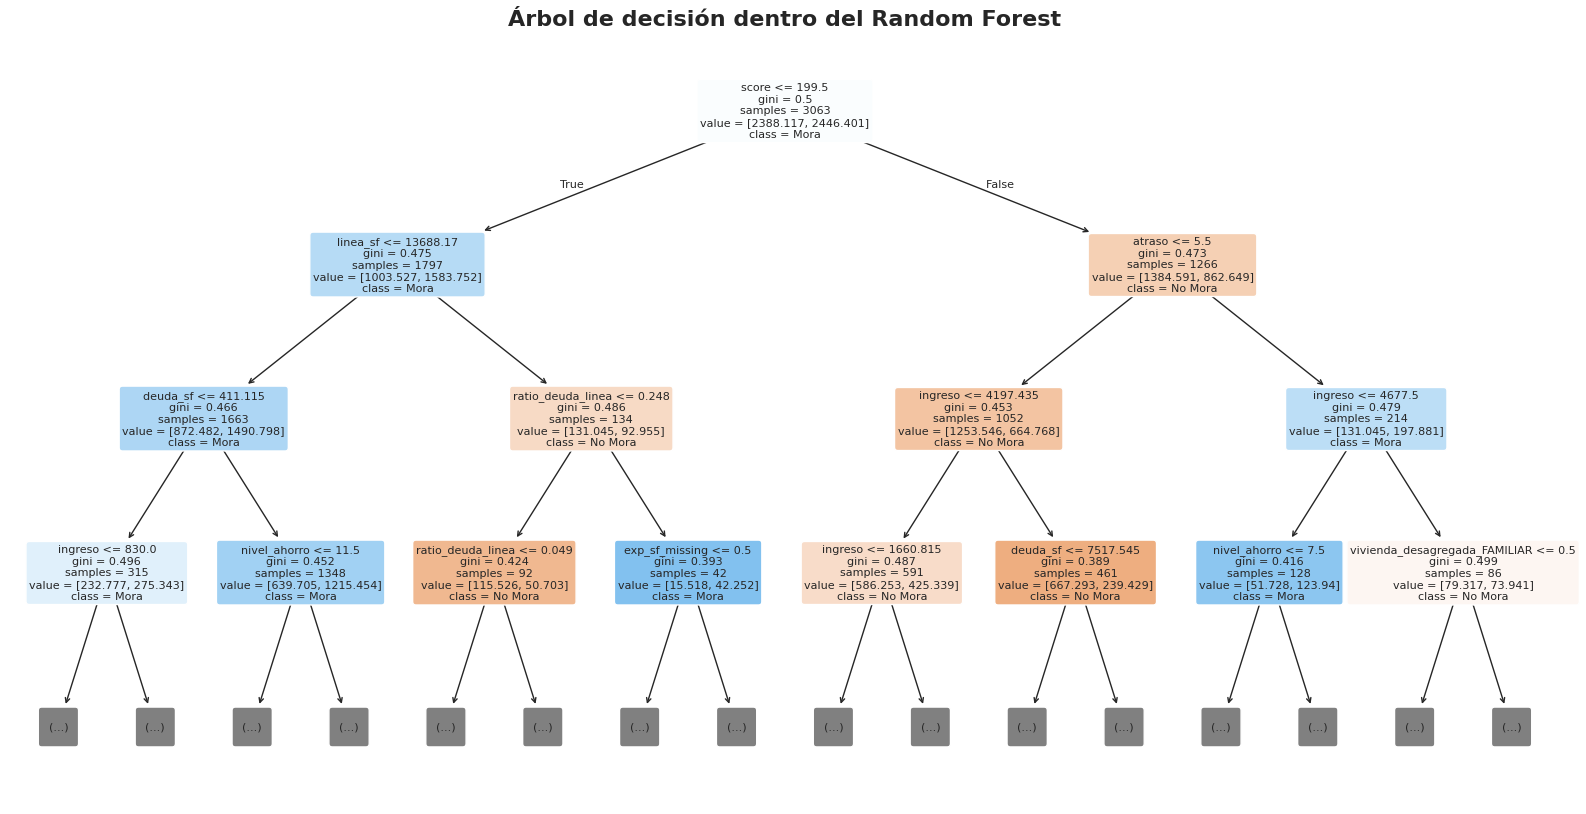

In [ ]:
## Gráficamos una muestra del árbol de decisiones

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# seleccionar un árbol del bosque
tree = best_rf.estimators_[0]

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['No Mora', 'Mora'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title(
    'Árbol de decisión dentro del Random Forest',
    fontsize=16,
    fontweight='bold'
)

plt.show()

***árbol de decisiones de random forest***

- el score es el principal organizador del riesgo (primer corte: score <= 199.5 MORA)  luego intervienen linea_sf, atraso, deudo, ratio_deuda e ingreso. El modelo construye perfiles en base a la vulnerabilidad financiera


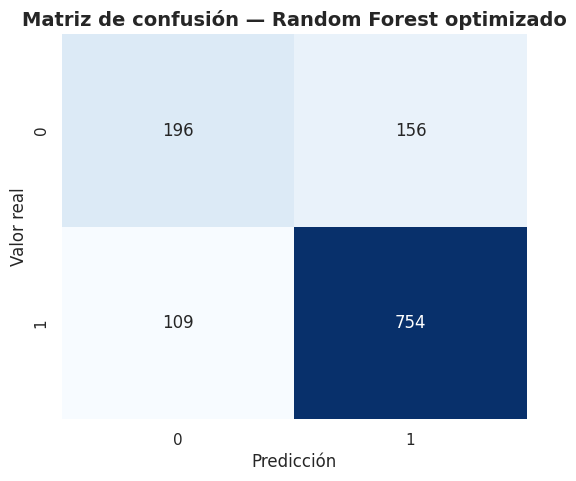

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title(
    'Matriz de confusión — Random Forest optimizado',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.show()

#***Matriz de confusión***

La matriz de confusión complementa el reporte de clasificación. Evalúa el rendimiento de un modelo de clasificación comparando las predicciones realizadas con los valores reales.

|Predicción| Acierto | Error | Total| Analisis|
|---|---|---|---|---|
| Mora| 754 (82%)| 156 (18%)| 910 (100%)| El modelo tiene una gran capacidad de predecir la mora
| No mora| 196 (64%)| 109 (36%)| 305 (100%)| El modelo tiende a calificar clientes un porcentaje menor, pero significativo de no morosos como mora

La matríz de confusión evidencia que el modelo tiene una gran capacidad de predecir la mora (82% de aciertos), pero tiende a considerar una tercera parte de clientes no morosos como morosos.

In [ ]:
#evaluamos con ROC-AUC

from sklearn.metrics import roc_auc_score

# definimos y_proba para evalular el modelo con ROC-AUC.
# Esta metrica requiere datos probabilisticos y no con datos binarios.
y_proba = best_rf.predict_proba(X_test)[:,1]


print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.8106565363952386


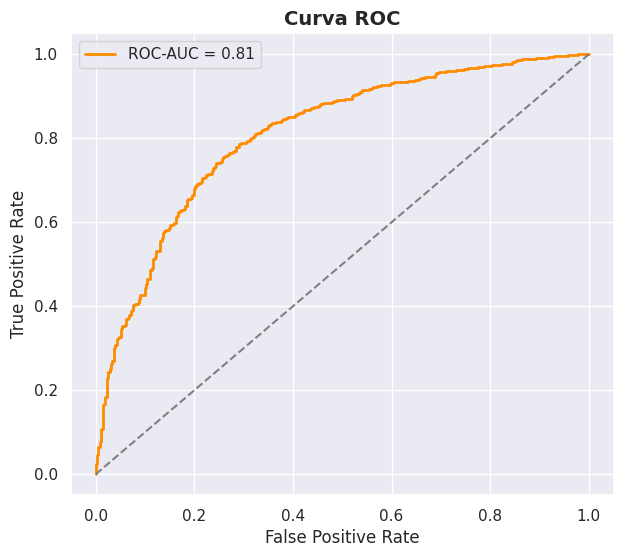

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    linewidth=2,
    label=f'ROC-AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'Curva ROC',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.show()


#***ROC-AUC***
- Roc-AUC evalúa que tan eficaz es el modelo para separar a morosos y no morosos.

- ROC-AUN de 0.81 implica que el modelo es muy bueno en separar ambas clases.

In [ ]:
from sklearn.metrics import average_precision_score

print("PR-AUC:", average_precision_score(y_test, y_proba))

PR-AUC: 0.9026567270203281


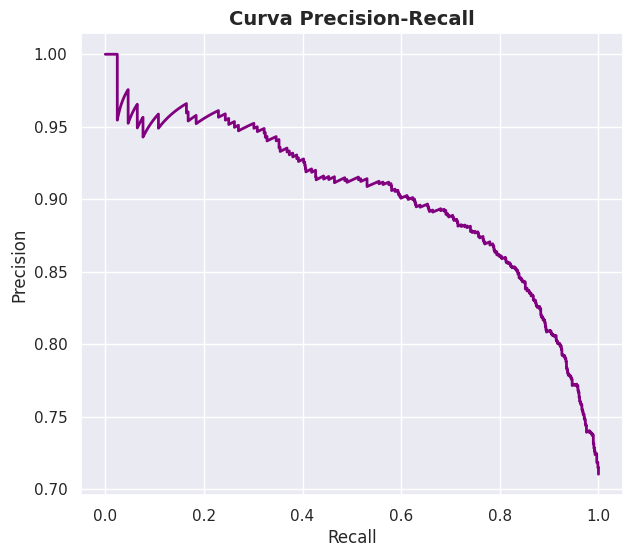

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    color='purple',
    linewidth=2
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title(
    'Curva Precision-Recall',
    fontsize=14,
    fontweight='bold'
)

plt.show()

#***PR-AUC***

- PR-AUC evalúa la capacidad de mantener la "precisión" mientras aumenta "recall"
- PR-AUC de 0.90 implica que el modelo en "excelente" en lograr captar muchos morosos sin perder totalmente precisión.

In [ ]:
## Umbrales de clasificación

#Evaluamos posibles ajustes del umbral para balancear el modelo de clasificación.
#En este caso evaluamos el threshold (umbral) en 0.2, 0.25, 0.3, 0.35, 0.4 y 0.5.

# Threshold bajo debería detectar más clientes morosos, aunque probablemente incluya más falsos positivos.

# Threshold alto debería detectar menos falsos positivos, aunque se escaparían morosos.

from sklearn.metrics import (
    classification_report,
    precision_recall_curve
)

# =========================
# Probabilidades de mora
# =========================

y_proba_rf = best_rf.predict_proba(X_test)[:,1]

# =========================
# Curva Precision-Recall
# =========================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba_rf
)

# =========================
# Evaluación de thresholds
# =========================

for thr in [0.4, 0.45, 0.5, 0.55, 0.60, 0.65]:

    # aplicar threshold sobre probabilidades
    y_pred_adj_rf = (y_proba_rf >= thr).astype(int)

    print("\n" + "="*50)
    print(f"Umbral: {thr}")
    print("="*50)

    print(
        classification_report(
            y_test,
            y_pred_adj_rf
        )
    )


Umbral: 0.4
              precision    recall  f1-score   support

           0       0.74      0.24      0.37       352
           1       0.76      0.97      0.85       863

    accuracy                           0.76      1215
   macro avg       0.75      0.60      0.61      1215
weighted avg       0.75      0.76      0.71      1215


Umbral: 0.45
              precision    recall  f1-score   support

           0       0.71      0.32      0.44       352
           1       0.77      0.95      0.85       863

    accuracy                           0.76      1215
   macro avg       0.74      0.63      0.65      1215
weighted avg       0.75      0.76      0.73      1215


Umbral: 0.5
              precision    recall  f1-score   support

           0       0.68      0.46      0.55       352
           1       0.81      0.91      0.86       863

    accuracy                           0.78      1215
   macro avg       0.74      0.69      0.70      1215
weighted avg       0.77      0.78 

# *** Ajuste del threshold***

- conservamos el umbral de 0.55 equivalente a los parametros previos, ya que presenta el mejor equilibrio entre la detección de clientes morosos y no morosos.

In [ ]:
y_proba_best_rf = best_rf.predict_proba(X_test)[:,1]

threshold = 0.55

y_pred_best_rf = (
    y_proba_best_rf >= threshold
).astype(int)

In [ ]:
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_best_rf))

print("Matthews Correlation Coefficient:",
      matthews_corrcoef(y_test, y_pred_best_rf))

print("Cohen's Kappa:",
      cohen_kappa_score(y_test, y_pred_best_rf))


Balanced Accuracy: 0.7152572948488359
Matthews Correlation Coefficient: 0.4503954428182072
Cohen's Kappa: 0.44823361066602696


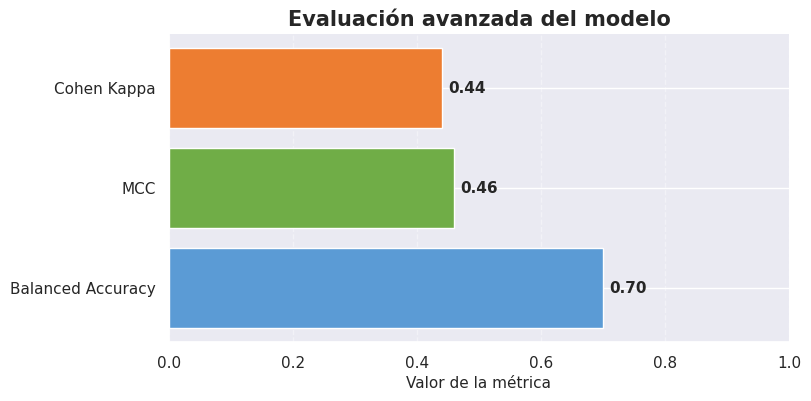

In [ ]:
metricas = {
    'Balanced Accuracy': 0.70,
    'MCC': 0.46,
    'Cohen Kappa': 0.44
}

plt.figure(figsize=(8,4))

bars = plt.barh(
    list(metricas.keys()),
    list(metricas.values()),
    color=['#5b9bd5', '#70ad47', '#ed7d31']
)

# etiquetas
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.xlim(0,1)

plt.xlabel(
    'Valor de la métrica',
    fontsize=11
)

plt.title(
    'Evaluación avanzada del modelo',
    fontsize=15,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

sns.despine()

plt.show()

Dado el desbalance existente entre clientes morosos y no morosos, se incorporaron métricas robustas para clasificación desbalanceada, tales como Balanced Accuracy, Matthews Correlation Coefficient y Cohen’s Kappa, con el objetivo de evaluar el desempeño real del modelo más allá de la accuracy general

| Metrica| Descripción | Resultado | Interpretación |
|---|---|---|---|
|Balanced Accuracy ("precisión equilibrada") |equilibra la accuracy en dataset desbalanceados. Su propósito es asegurar que el modelo funcione bien en las clases minoritarias| 0.70| El modelo logra balancear bien la clase mayortitaria y la minoritaria|
|MCC (Matthews Correlation Coefficient)|  Evalua la calidad de las clasificaciones binarias en el aprendizaje automático.Una puntuación MCC alta solo se consigue si un modelo funciona bien tanto en la clase mayoritaria como en la minoritar | 0.46| Correlación razonable (-1 totalmente incorrecto, 0 azar, 1 perfecto)
|Cohen's Kappa| evalúa cuánto mejora el modelo respecto al azar| 0.44| El modelo mejora los resultado en relación al azar|


In [ ]:
# analis de "importancia". Se observan las variables de mayor relevancia en el modelo
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

,0
ingreso,0.130940
score,0.113804
linea_sf,0.099481
ratio_deuda_linea,0.095646
deuda_sf,0.091779
edad,0.090067
anios_lab,0.071318
exp_sf_anios,0.069842
atraso,0.056320
nivel_ahorro,0.043961


/tmp/ipykernel_39464/727251185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


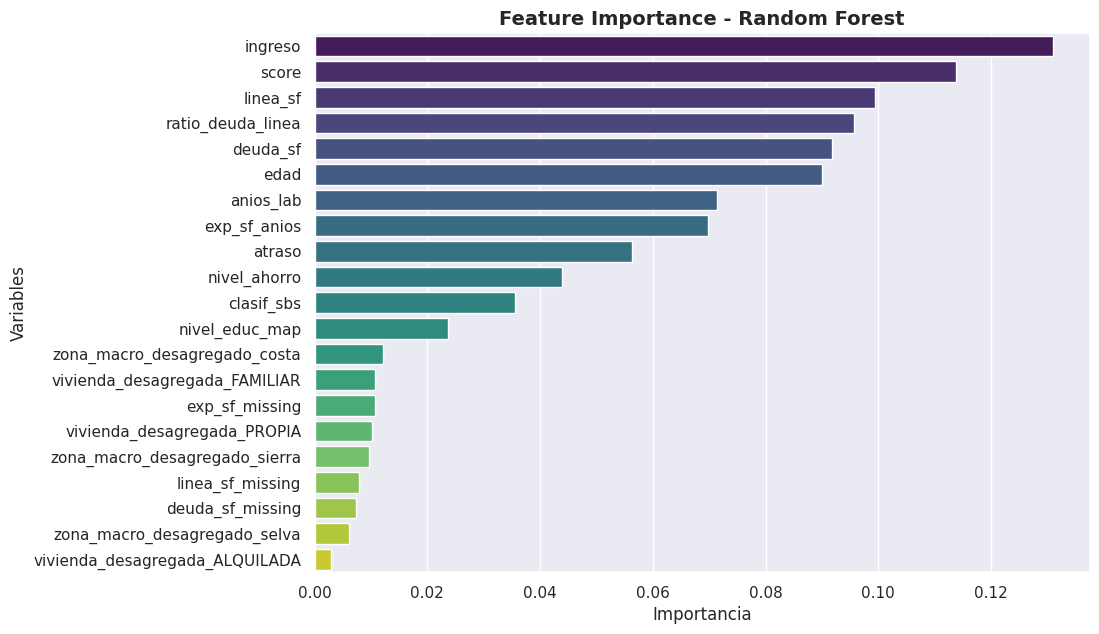

In [ ]:
# Gráfico feature importance - random forest
#feature importance analiza cuánto uso el modelo de estas variables para dentro de los árboles
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,7))

sns.barplot(
    x=importances.values,
    y=importances.index,
    palette='viridis'
)

plt.title(
    'Feature Importance - Random Forest',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importancia')
plt.ylabel('Variables')

plt.show()

#***Insigth***

- Las importancias combinan variables sociodemográficas y variables financieras
- Las variables más importantes son Ingreso, score, linea_sf, ratio_deduda y edad.
- Variables como nivel educativo, zona de residencia y tipo de vivienda tienen menor importancia

/tmp/ipykernel_39464/427673220.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


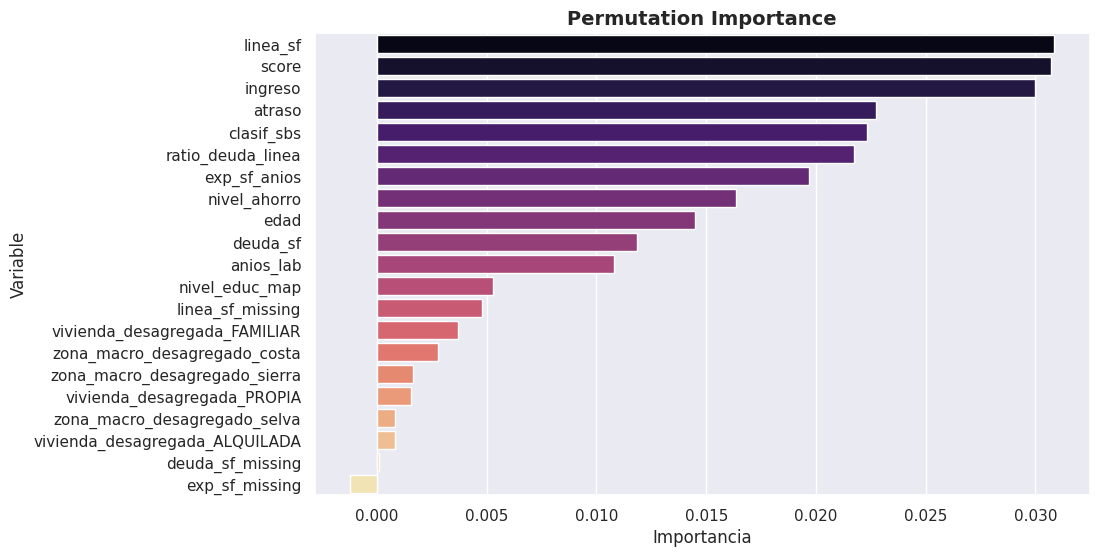

In [ ]:
#Permutation importance evalúa cuánto depende el rendimiento predictivo del modelo de esa variable una vez entrenado
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia': perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by='Importancia',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=perm_df,
    x='Importancia',
    y='Variable',
    palette='magma'
)

plt.title(
    'Permutation Importance',
    fontsize=14,
    fontweight='bold'
)

plt.show()

#***Insight***

Permutation importance evalúa cuánto depende el rendimiento predictivo del modelo de esa variable una vez entrenado.

- Observamos que tres variables que encabezan feature importancia también lo hacen en permutance importance: Ingreso, score, linea_sf. Sin embargo, atraso y clasif_sbs ocupan una posición de mayor importancia que ratio_deduda y edad.
- Permutatation importance cmplementa y convalida feature importance

#***Clasificación de perfiles de riesgo***
Esta sección se realiza una clasificación de perfiles de riesgo según la probabilidad de mora "baja", 'Medio bajo','medio','medio alta' y 'Alta'.

Luego se realiza un analisis vivariado y multivariado sobre variables sociodemográficas y financieras seleccionadas.

In [ ]:
#creamos variables predictoras de mora
import pandas as pd

segmentos = pd.cut(
    y_proba_rf,
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=['Bajo', 'Medio bajo','medio','medio alto', 'Alto']
)

segmentos.describe()

,counts,freqs
categories,,
Bajo,16,0.013169
Medio bajo,100,0.082305
medio,275,0.226337
medio alto,473,0.389300
Alto,351,0.288889


In [ ]:
#creamos data set analitico

df_segmentacion = X_test.copy()

df_segmentacion['prob_mora'] = y_proba

df_segmentacion['segmento_riesgo'] = segmentos

df_segmentacion['mora_real'] = y_test.values

df_segmentacion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1215 entries, 6047 to 2013
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   atraso                          1215 non-null   float64 
 1   edad                            1215 non-null   float64 
 2   nivel_ahorro                    1215 non-null   float64 
 3   ingreso                         1215 non-null   float64 
 4   linea_sf                        1215 non-null   float64 
 5   deuda_sf                        1215 non-null   float64 
 6   score                           1215 non-null   float64 
 7   clasif_sbs                      1215 non-null   float64 
 8   exp_sf_missing                  1215 non-null   float64 
 9   linea_sf_missing                1215 non-null   float64 
 10  deuda_sf_missing                1215 non-null   float64 
 11  ratio_deuda_linea               1215 non-null   float64 
 12  vivienda_desagregada_A

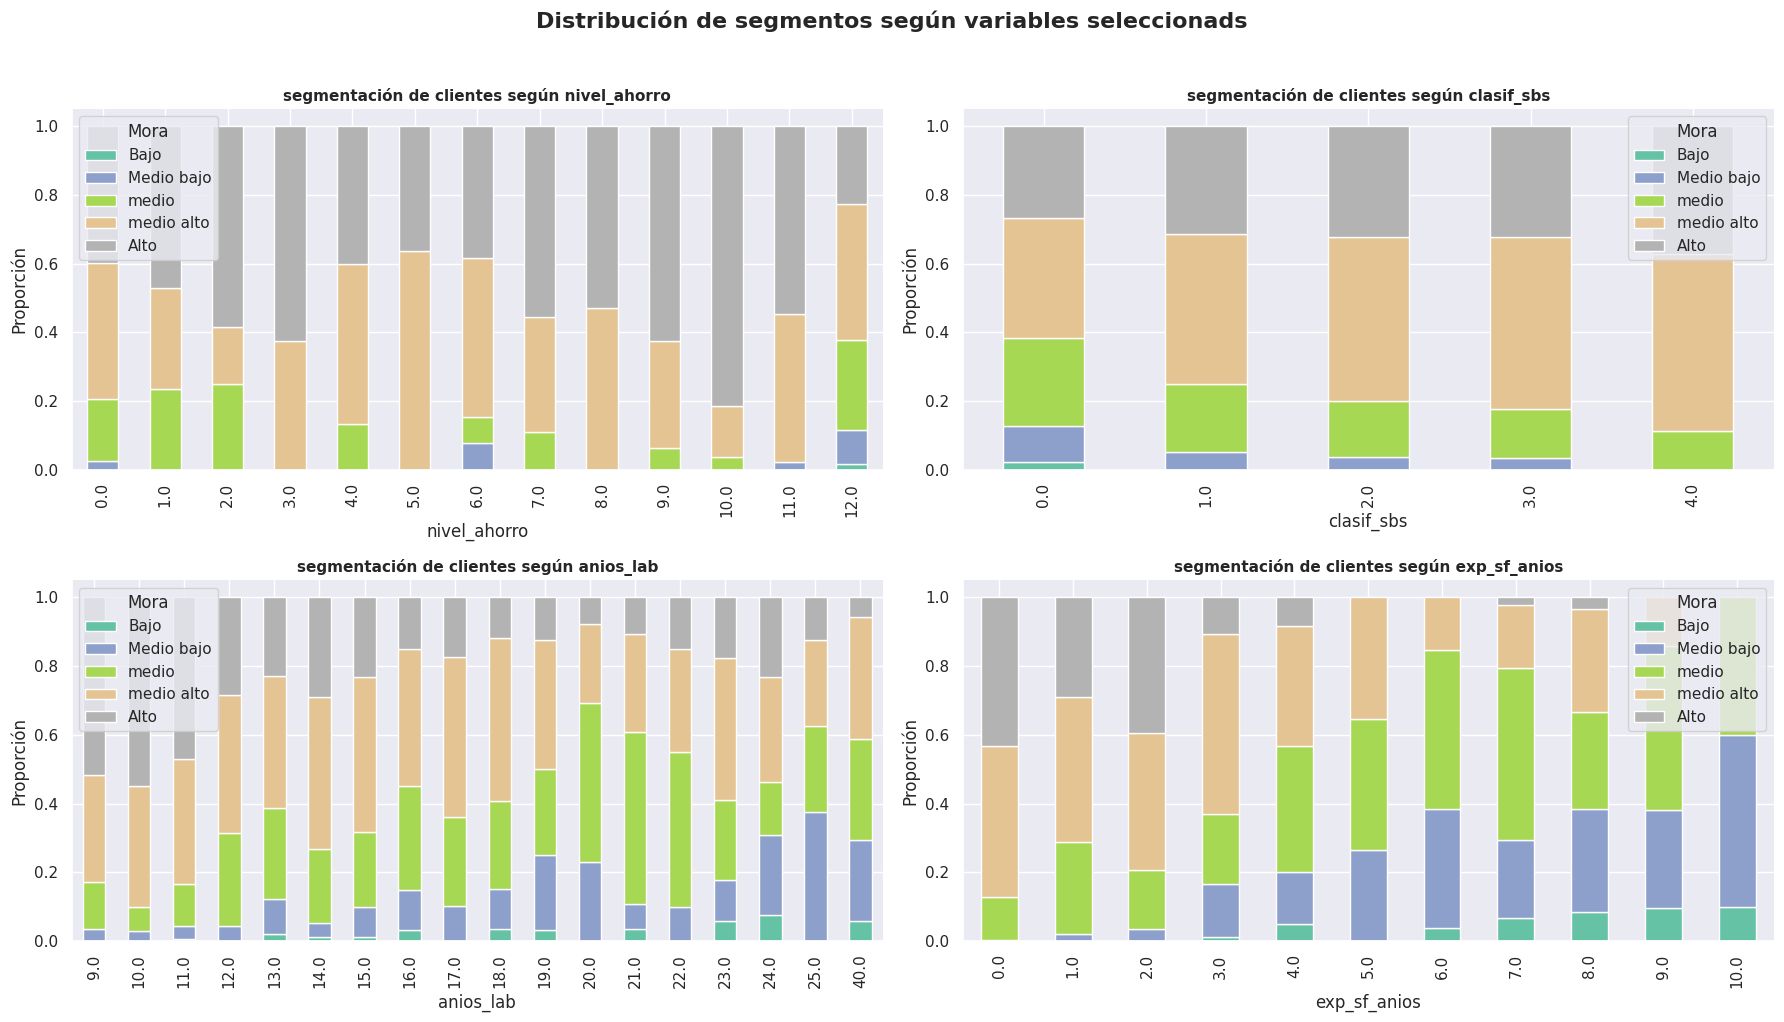

In [ ]:
variables_cat = [
    'nivel_ahorro',
    'clasif_sbs',
    'anios_lab',
    'exp_sf_anios',
]



n_cols = 2
n_rows = math.ceil(len(variables_cat) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(variables_cat):

    tabla = pd.crosstab(
        df_segmentacion[col],
        df_segmentacion['segmento_riesgo'],
        normalize='index'
    )

    tabla.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        colormap='Set2'
    )

    axes[i].set_title(
        f'segmentación de clientes según {col}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].set_ylabel('Proporción')

    axes[i].legend(title='Mora')

    sns.despine(ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Distribución de segmentos según variables seleccionads',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()



#***

| | |

/tmp/ipykernel_39464/2406015145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/2406015145.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/2406015145.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_39464/2406015145.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_39464/2406015145.py:69: FutureWarni

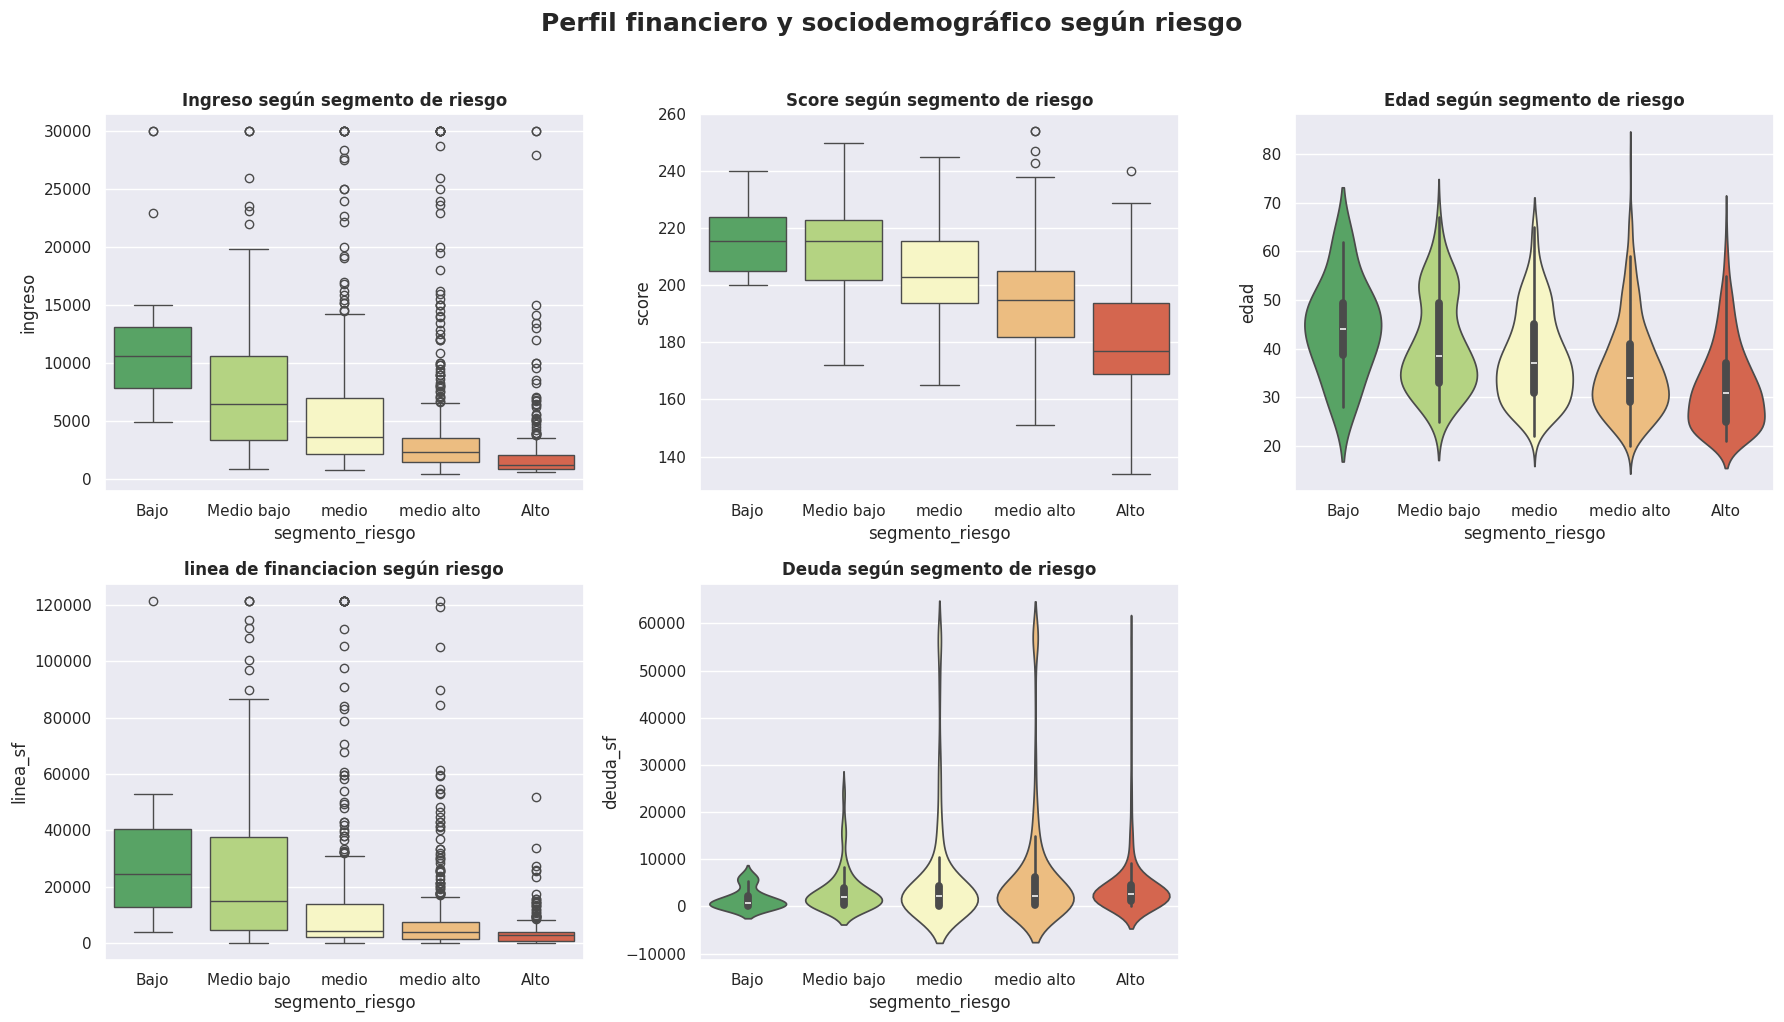

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ===== INGRESO =====

sns.boxplot(
    data=df_segmentacion,
    x='segmento_riesgo',
    y='ingreso',
    palette='RdYlGn_r',
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Ingreso según segmento de riesgo',
    fontsize=12,
    fontweight='bold'
)

# ===== SCORE =====

sns.boxplot(
    data=df_segmentacion,
    x='segmento_riesgo',
    y='score',
    palette='RdYlGn_r',
    ax=axes[0,1]
)

axes[0,1].set_title(
    'Score según segmento de riesgo',
    fontsize=12,
    fontweight='bold'
)

# ===== EDAD =====

sns.violinplot(
    data=df_segmentacion,
    x='segmento_riesgo',
    y='edad',
    palette='RdYlGn_r',
    ax=axes[0,2]
)

axes[0,2].set_title(
    'Edad según segmento de riesgo',
    fontsize=12,
    fontweight='bold'
)

# ===== NIVEL AHORRO =====

sns.boxplot(
    data=df_segmentacion,
    x='segmento_riesgo',
    y='linea_sf',
    palette='RdYlGn_r',
    ax=axes[1,0]
)

axes[1,0].set_title(
    'linea de financiacion según riesgo',
    fontsize=12,
    fontweight='bold'
)

# ===== DEUDA =====

sns.violinplot(
    data=df_segmentacion,
    x='segmento_riesgo',
    y='deuda_sf',
    palette='RdYlGn_r',
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Deuda según segmento de riesgo',
    fontsize=12,
    fontweight='bold'
)

# Eliminar gráfico vacío
fig.delaxes(axes[1,2])

plt.suptitle(
    'Perfil financiero y sociodemográfico según riesgo',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

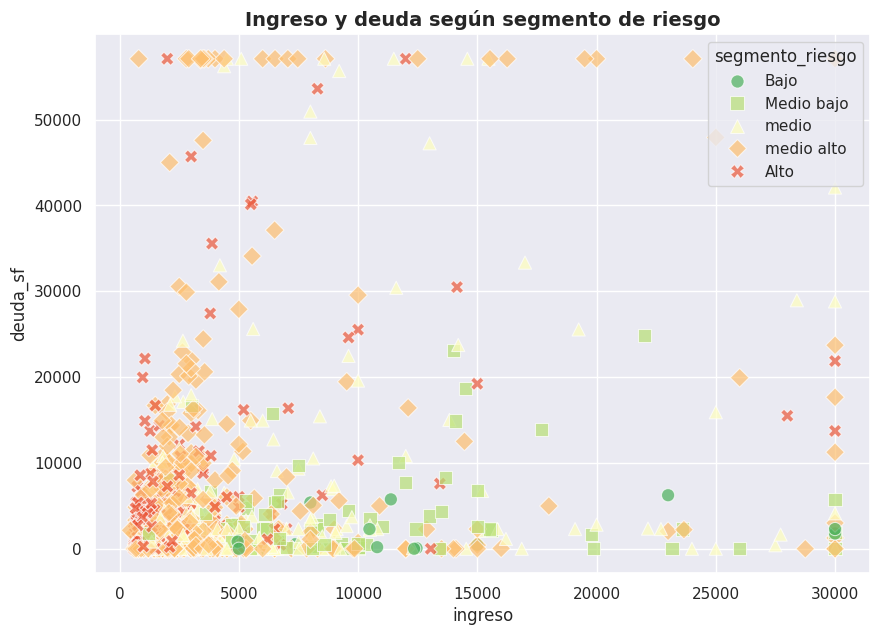

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_segmentacion,
    x='ingreso',
    y='deuda_sf',
    hue='segmento_riesgo',
    style='segmento_riesgo',
    markers={
        'Bajo': 'o',
        'Medio bajo': 's',
        'medio': '^',
        'medio alto': 'D',
        'Alto': 'X'
    },
    alpha=0.7,
    s=90,
    palette='RdYlGn_r'
)

plt.title(
    'Ingreso y deuda según segmento de riesgo',
    fontsize=14,
    fontweight='bold'
)

plt.show()

/tmp/ipykernel_39464/2713507257.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perfil = df_segmentacion.groupby(


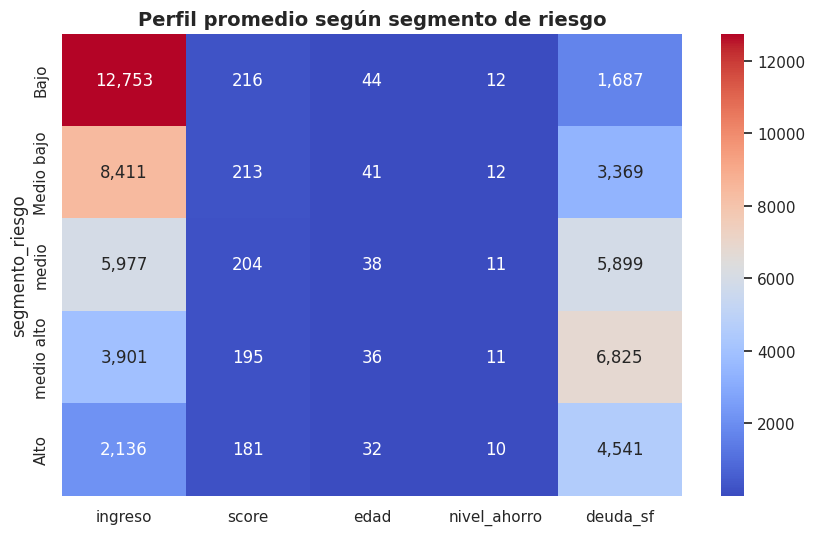

In [ ]:
perfil = df_segmentacion.groupby(
    'segmento_riesgo'
)[
    [
        'ingreso',
        'score',
        'edad',
        'nivel_ahorro',
        'deuda_sf'
    ]
].mean()

plt.figure(figsize=(10,6))



sns.heatmap(
    perfil,
    annot=True,
    fmt=',.0f',
    cmap='coolwarm'
)

plt.title(
    'Perfil promedio según segmento de riesgo',
    fontsize=14,
    fontweight='bold'
)

plt.show()

***Insight***

Heatmap promedio evalua el perfíl promedio de variables de los distintos segmentos de riesgo según variables seleccionadas. Este grafico, permite visualizar como se distribuye una variable en el segmento de riesgo.

El heatmap muestra
| Variable| Descripción |
|---|---|
| Ingreso|Los clientes de segmento de "riesgo bajo" tienen un promedio de ingresos de $10.993. Por el contrario, en el segmento de "riesgo alto" el promedio es de $2577|
| Score|  En segmento de "riesgo bajo" el Score promedio es alto (220). Por el contrario, segmento de "riesgo alto" tiene un promedio menor (184)|
| Edad |  Riesgo bajo encuentra edades maduras (promedio 41-47 años). Por el contrario, en riesgo alto, el promedio de edad es menor (promedio 33-36)|
| Nivel de Ahorro| Los distintos perfiles muestran un nivel de ahorro similar 10, 11 y 12 (ordinal, 1 a 12)|
| Deuda | En bajo riesgo  el promedio de deuda es de $2100 y en riesgo alto de $5121. Esto indica que a mayor deuda más riesgo de mora. Sin embargo, a diferencia de las anteriores variables, la deuda no crece linealmente por segmento |

***Sintesis***
- El heatmap resume el perfil promedio de los distintos segmentos de riesgo identificados por el modelo.
- Los clientes clasificados como bajo riesgo presentan mayores ingresos, mejor score crediticio, mayor edad y menor nivel de endeudamiento promedio.
- En contraste, los segmentos de alto riesgo muestran menores ingresos, peores scores y menor capacidad de ahorro, sugiriendo una mayor vulnerabilidad financiera estructural.

#***Conclusiones y recomendaciones***

El incumplimiento de obligaciones financieras constituye uno de los principales riesgos de las entidades financieras ya que impacta negativamente sobre la rentabilidad, el valor bursatil y la recuperación de créditos. En este contexto, el objetivo de  este proyecto fue desarrollar un modelo capaz de estimar la probabilidad de mora de los clientes a partir de técnicas de aprendizaje supervisado. El punto de partida fue la inquietud acerca de la eficacia de los instrumentos de clasificación de clientes vigentes en captar la probalidad de mora.

***Analisis exploratorio***

El Analisis exploratorio de datos permitio identificar un perfíl de cliente mayormente jóven (Edad entre 30 a 40 años), con formación técnica y universitaria, residente mayormente en la costa y habitantes de viviendas familiares. Desde el punto de vista del pérfil financiero, los ingresos, línea de financiamiento y deuda se concentran en montos medios a bajos, aunque existe una minoría con montos elevados. Asimismo, la experiencia en el sistema financiero es baja –mayormente entre 0 y 2 años- y los clientes son calificados mayormente como clientes “normales”, aunque poseen un score bajo (media 190)
Para la clasificación de implemento un modelo Random-Forest que permitió diferenciar de manera eficientes grupos morosos de no morosos. El modelo acerto en el 91% de clientes morosos y en un 49% de clientes sin mora. Esto implica que el algorítmo es muy bueno acertando clientes con mora, pero tiende a sobreestimar parcialmente la probabilidad de mora, acusando a clientes no morosos de riesgo crediticio.

*** Modelo de Clasificación Random Forest***

El analisis de árbol de decisiones y de importancias identifica que las variables más significativas del modelo fueron: ingreso, score, línea y ratio de deuda. Estos resultados sugieren que el riesgo crediticio se encuentra fuertemente asociado tanto a la capacidad económica del cliente como a su historial financiero .El nivel educativo alcanzado, la zona de residencia y el tipo de vivienda fueron menos relevantes. La menor importancia en estas variables corresponde a la distribución fuertemente sesgada que presenta el dataset.

*** Segmentación probabilistica de riesgo de mora***

Finalmente, se realizó una segmentación probabilistica del riesgo de mora, clasificando a los clientes en cinco pérfiles: bajo, medio bajo, medio, medio alto y alto riesgo. Esta segmentación permitió identificar perfiles financieros y sociodemográficos diferenciados, observándose que los clientes de mayor riesgo presentan menores ingresos, peores scores crediticios, menor capacidad de ahorro y menor antigüedad dentro del sistema financiero. En comparación con la “clasificación” originaria del dataset y el score del cliente, esta segmentación permitió diferenciar con mayor claridad los perfiles de riesgo.

***Contribución al negocio***

Desde el punto de vista de negocio, el modelo desarrollado puede contribuir a mejorar los mecanismos de evaluación crediticia, permitiendo optimizar políticas de otorgamiento, seguimiento y prevención de riesgo. Asimismo, la segmentación probabilística puede utilizarse para diseñar estrategias diferenciadas de monitoreo y gestión de clientes según su perfil de riesgo.


In [ ]:
!jupyter nbconvert --to html "/content/Modelo_clasificación_Mora_Bancaria.ipynb"

[NbConvertApp] WARNING | pattern '/content/Modelo_clasificación_Mora_Bancaria.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterAp

In [ ]:
from google.colab import files
files.download('Modelo_clasificación_Mora_Bancaria.html')

FileNotFoundError: Cannot find file: Modelo_clasificación_Mora_Bancaria.html